In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from datetime import date
import math
from tqdm import tqdm
from collections import defaultdict
import psutil
import shutil
import gc
from lightgbm import LGBMRanker
tqdm.pandas()

<h1 style="color:red;">Podesavanja Pandas-a</h1>

<p style="color:black;">
    Uvijek uzimamo sve kolone kada radimo prikaz. <br> Podesavam da sirina ekrana i maksimalan broj kolona nemaju ogranicenja. Odnosno prikazujem sve kolone.<br>
    Broj redova ogranicavam na 20, ovo je korisno jer se zna desiti da jupyter crash-a ako je preveliki DataFrame i mora prikazati bukvalno sve podatke.
</p>

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_rows', 20)

#Kada hocu privremeno prikazati cijeli df
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    print(df)

<h1 style="color:red;">Učitavanje tabela sa kojim radim</h1>

<p style="color:black;">
    Pošto Pandas nekad ne može da sam shvati koji je tip kolone, za pojedine sam morao eksciplitno navesti u dtype.
    Za produkcionu verziju ručno navesti za svaku kolonu.
</p>

In [3]:
policy_data = pd.read_csv('../data/data_from_db_as_csv/new_polisa_202603141519.csv', dtype = {
    'ponuda_id': 'Int32',
    'ugo_jmbg': str
})

ins_cli_data = pd.read_csv('../data/data_from_db_as_csv/__ins_klijenti__202603141320.csv', dtype = {
    'mat_br': str,
    'klijent_id': 'Int32'
})

np_cli_data = pd.read_csv('../data/data_from_db_as_csv/new_polisa_klijent_202603141515.csv',
    dtype={
        'osig_jmbg': str,
        'klijent_id': 'Int32',
        'ponuda_id': 'Int32'
    })

cli_roles = pd.read_csv('../data/data_from_db_as_csv/new_polisa_uloga_202603172039.csv')

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_18524\4152338430.py:1: DtypeWarning: Columns (61,65,80,82) have mixed types. Specify dtype option on import or set low_memory=False.
  policy_data = pd.read_csv('../data/data_from_db_as_csv/new_polisa_202603141519.csv', dtype = {
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_18524\4152338430.py:11: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  np_cli_data = pd.read_csv('../data/data_from_db_as_csv/new_polisa_klijent_202603141515.csv',


<h1 style="color: red;">Provjera za kasnije da li dolazi do eksplozije prilikom merge-a</h1>

In [4]:
def print_duplicates(df, subset):
    
    print("\n")
    print("############ DUPLICATES CHECK ##############")
    print("############ EXPLOSION CHECK ##############")
    print(subset)
          

    df = df.copy()

    # ---------------------------------------------------------
    # 1. duplicated() -> broji "kasnije" duplikate
    # ---------------------------------------------------------
    # Ako postoji:
    # (1, A)
    # (1, A)
    #
    # prvi red = False
    # drugi red = True
    #
    # sum() samo prebroji koliko True vrijednosti postoji.
    # ---------------------------------------------------------
    print(
        "Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... :",
        df.duplicated(
            subset=subset
        ).sum()
    )



    # ---------------------------------------------------------
    # 2. groupby() pristup
    # ---------------------------------------------------------
    # Grupiše po:
    #   ponuda_id + candidate_type
    #
    # size() -> koliko redova ima svaka grupa
    #
    # gt(1) -> True ako grupa ima vise od 1 reda
    #
    # sum() -> koliko TAKVIH grupa postoji
    #
    # VAŽNO:
    # Ovo NE broji broj redova duplikata,
    # nego broj grupa koje imaju duplikate.
    # ---------------------------------------------------------
    print(
        "Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... :",
        df.groupby(subset).size().gt(1).sum()
    )



    # ---------------------------------------------------------
    # 3. keep=False
    # ---------------------------------------------------------
    # duplicated(..., keep=False)
    #
    # Označi SVE članove duplikat grupe kao True.
    #
    # Primjer:
    #
    # (1, A) -> True
    # (1, A) -> True
    #
    # shape[0] -> broj redova
    #
    # Ovo vraća UKUPAN broj redova
    # koji pripadaju duplikat grupama.
    # ---------------------------------------------------------
    print(
        "Ukupno redova koji pripadaju duplikat grupama:",
        df[
            df.duplicated(
                subset=subset,
                keep=False
            )
        ].shape[0]
    )



    # ---------------------------------------------------------
    # 4. Prikaz samih duplikata
    # ---------------------------------------------------------
    # Filtrira samo redove koji su duplikati
    # i sortira ih radi lakšeg pregleda.
    # ---------------------------------------------------------
    # print(
    #     df[
    #         df.duplicated(
    #             subset=subset,
    #             keep=False
    #         )
    #     ].sort_values(
    #         ['ponuda_id', 'candidate_type']
    #     )
    # )

    print("############ END ##############")
    print("\n")

In [5]:
print_duplicates(policy_data, ['ponuda_id'])
print_duplicates(np_cli_data, ['ponuda_id'])
print_duplicates(np_cli_data, ['ponuda_id', 'sif_uloga'])
print_duplicates(np_cli_data, ['ponuda_id', 'klijent_id', 'sif_uloga'])



############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 0
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 0
Ukupno redova koji pripadaju duplikat grupama: 0
############ END ##############




############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 23816
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 23700
Ukupno redova koji pripadaju duplikat grupama: 47516
############ END ##############




############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id', 'sif_uloga']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id

<h1 style="color:red;">Ispis zanimljivih datumskih kolona i fe za iste.</h1>

<p style="color:black;">
    Kreiramo novu kolonu godine, na onsovu datuma izdavanja.
    Od nje pravimo još 2 odnosno koliko je polisa stara u godinama i u danima.
</p>

In [9]:
# 1. konverzija u datetime
# policy_data['dat_izdavanja'] = pd.to_datetime(policy_data['dat_izdavanja'], errors='coerce')
policy_data['dat_izdavanja'] = pd.to_datetime(policy_data['dat_izdavanja'])

# 2. broj redova po godini
policy_data['godina'] = policy_data['dat_izdavanja'].dt.year
counts = policy_data['godina'].value_counts().sort_index()
policy_data['days_old'] = (pd.Timestamp.today() - policy_data['dat_izdavanja']).dt.days
policy_data['years_old'] = policy_data['days_old'] / 365.25

print(counts)

godina
2024     7981
2025    87169
2026     2788
Name: count, dtype: int64


In [10]:
print(f"np_cli_data: {np_cli_data.shape[0]} redova")
print(f"ins_cli_data: {ins_cli_data.shape[0]} redova")

np_cli_data: 114343 redova
ins_cli_data: 54967 redova


In [11]:
cli_data = ins_cli_data.merge(np_cli_data, on="klijent_id", how="inner")

print(f"cli_data poslije merge-a: {cli_data.shape[0]} redova")
print(f"cli_data poslije brisanja duplikata: {cli_data.drop_duplicates(['klijent_id', 'redni_br']).shape[0]} redova")

cli_data poslije merge-a: 114130 redova
cli_data poslije brisanja duplikata: 54736 redova


In [12]:
print(f'np_cli_data nan klijent_id ukupno: {np_cli_data["klijent_id"].isna().sum()}')
print(f'ins_cli_data nan klijent_id ukupno: {ins_cli_data["klijent_id"].isna().sum()}')

np_cli_data nan klijent_id ukupno: 213
ins_cli_data nan klijent_id ukupno: 0


<h1 style="color:red;">Funkcija gather_cli_info_fastest</h1>

<p style="color:black;">
Ova funkcija služi da za svakog klijenta formira jedan kompletan zapis, tako što spaja informacije iz više redova i uklanja nedostajuće vrijednosti na efikasan način koristeći Pandas operacije.
</p>

<ol>

<li>
<b>df.sort_values('klijent_id')</b> - sortira DataFrame po identifikatoru klijenta.
<br>
<small>
Razlog: osigurava da su svi redovi istog klijenta grupisani zajedno, što je važno za dalju obradu.
</small>
</li>

<li>
<b>df.groupby('klijent_id').transform('bfill')</b> - vrši grupisanje po klijent_id i popunjava nedostajuće vrijednosti (NaN) koristeći <i>backward fill</i>.
<br>
<small>
To znači da se prazne vrijednosti popunjavaju prvim sljedećim dostupnim vrijednostima unutar iste grupe (odozdo prema gore).
<br>
Na ovaj način se “rekonstruišu” podaci iz više redova istog klijenta.
</small>
</li>

<li>
<b>df_filled['klijent_id'] = df['klijent_id'].values</b> - vraća klijent_id nazad u DataFrame.
<br>
<small>
Pošto <code>transform</code> ne zadržava originalni ključ kao kolonu, on se ručno vraća iz originalnog DataFrame-a.
</small>
</li>

<li>
<b>df_filled.drop_duplicates('klijent_id', keep='first')</b> - uklanja duplikate i ostavlja samo jedan red po klijentu.
<br>
<small>
Rezultat je jedan “kompletan” zapis po svakom klijentu.
</small>
</li>

</ol>

<p style="color:black;">
<b>Rezultat:</b> DataFrame sa jednim redom po klijentu, gdje su sve nedostajuće vrijednosti popunjene iz drugih redova iste grupe.
</p>

<p style="color:black;">
<b>Suština:</b> Funkcija spaja više redova istog klijenta u jedan čisti zapis bez NaN vrijednosti.
</p>

<p style="color:black;">
<b>Dodatno:</b> <code>bfill()</code> koristi vrijednosti iz “budućih” redova, dok <code>ffill()</code> koristi prethodne (gornje) redove u grupi.
</p>

<h1 style="color:red;">GroupBy u Pandasu</h1>

<p style="color:black;">
    Kada koristimo <code>groupby</code> u Pandasu, postoje različiti načini obrade grupa:
</p>
<ul>
    <li>
        <b>agg</b> - radi sa <i>Series</i> objektima (tj. kolonama unutar grupe). 
        Zato zahtijeva agregatne funkcije koje se primjenjuju na niz vrijednosti, 
        poput <code>sum</code>, <code>mean</code>, <code>max</code>, <code>min</code>.
        <br>
        <small>Primjer: <code>df.groupby("klijent").agg({"iznos": "sum"})</code></small>
    </li>
    <li>
        <b>apply</b> - radi sa cijelim pod-DataFrame-om grupe. 
        Funkcija koju proslijedimo dobija sve redove grupe, pa možemo raditi kompleksnije operacije 
        (filtriranje, sortiranje, vraćanje prilagođenih rezultata).
        <br>
        <small>Primjer: <code>df.groupby("klijent").apply(lambda g: g[g["iznos"] == g["iznos"].max()])</code></small>
    </li>
    <li>
        <b>transform</b> - radi nad kolonama unutar grupe i vraća rezultat istog oblika kao originalni DataFrame.
        <br>
        <small>
        Za razliku od <code>agg</code> i <code>apply</code>, <code>transform</code> uvijek vraća isti broj redova kao ulaz.
        Svaka vrijednost u grupi se transformiše pojedinačno, ali zadržava originalnu strukturu podataka. <br>
        transform prosto ne ukljucuje kljuc od groupby u finalni rezultat transformacije. Da bi ga ukljucio potrebno je
        <br><b>df = df.groupby('klijent_id', group_keys=False).bfill()</b><br> Sto bi bio ekvivalent trenutnom kodu gdje radimo transform pa poslije vracamo klijent_id iz originalnog DataFrame-a
        <br><br>
        Najčešće se koristi za operacije poput <code>fillna</code>, standardizacije, normalizacije ili popunjavanja vrijednosti unutar grupa (npr. <code>bfill</code>, <code>ffill</code>).
        </small>
        <br>
        <small>Primjer: <code>df.groupby("klijent").transform("bfill")</code></small>
    </li>
</ul>

In [13]:
def gather_cli_info(df):
    df = df.copy()

    # bitno: moraš definisati redoslijed (inače "first" nema smisla)
    df = df.sort_values('klijent_id')

    return (
        df
        .groupby('klijent_id', as_index=False)
        .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
    )

def gather_cli_info_fastest(df):
    df = df.sort_values('klijent_id')
    df_filled = df.groupby('klijent_id').transform('bfill')
    df_filled['klijent_id'] = df['klijent_id'].values
    return df_filled.drop_duplicates('klijent_id', keep='first')


cli_data = gather_cli_info_fastest(cli_data)
# cli_data = cli_data.drop_duplicates('klijent_id', keep='first')

print(f"Poslije: {cli_data.shape[0]} redova (jedinstveni klijenti)")
print(f"\nPopunjenost (% ne-null):")
print((cli_data.notna().mean() * 100).round(1).to_string())

Poslije: 54109 redova (jedinstveni klijenti)

Popunjenost (% ne-null):
ind_rezident           100.0
sif_svojina            100.0
mat_br                  99.2
naziv                  100.0
naziv1                  89.5
king_id_x               94.6
ind_stranac              0.0
drzava_id_x              0.8
br_pasosa_x              0.8
datum_rodjenja_x         0.8
pol_id_x                89.5
dat_vozacke_x           10.6
sif_delatnost_x          4.3
nedef_delatnost_x        0.0
sif_bracni_status_x     11.6
mesto_rodj_x            11.7
ponuda_id              100.0
redni_br               100.0
sif_uloga              100.0
osig_jmbg               99.2
osig_svojina           100.0
osig_naziv             100.0
osig_naziv1             89.5
osig_ulica              99.5
osig_kuc_br             99.6
osig_mesto             100.0
osig_posta             100.0
osig_kanton             99.1
osig_opstina            99.1
osig_mesto_id           99.1
osig_telefon1           56.3
osig_telefon2            0.0
o

In [14]:
print(f'Dimenzije cli_data: {cli_data.shape}')

Dimenzije cli_data: (54109, 47)


<h1 style="color:red;">Matični broj obrada i ekstrakcija podataka.</h1>

<p style="color:black;">
    Tretiram vrijednosti koje i koje su duzine 13 karaktera. </br>
    Za svaki slucaj zfill(13) Dodaje 0 sa pocetka string-a dok ne bude 13 karaktera, ako je string kraci.</br>
    To radim za klijente koji su pravna llica i domaci
</p>
<p>Uzimam:</p>
<ul>
    <li>Godine</li>
    <li>Mjesto rođenja</li>
    <li>pol</li>
</ul>

In [15]:
def extract_serial_num_Data(serial_number):

    if pd.isna(serial_number) or serial_number == '' or len(serial_number) != 13:
        return np.nan, np.nan, np.nan

    sn = str(serial_number).zfill(13)
    
    year = int(sn[4:7])
    year = year + 2000 if year < 800 else 1000 + year
    age = date.today().year - year

    birth_place = sn[7:9]

    gender = 1 if int(sn[9:12]) < 500 else 0

    return age, birth_place, gender

<h1 style="color:red;">Čišćenje podataka</h1>

<p style="color:black;">

</p>
<p>Uzimam:</p>
<ul>
    <li>is_foreign - stranac - brisanje kolona iz kojih je izvucen podatak</li>
    <li>years - datum_rodjenja - posto sam godine vec izvukao iz maticnog broja merge-am - brisem zavisnosti</li>
    <li>pol - Vec izvucen iz maticnog i sada merge-am sa kolonama za unos - brisem zavisnosti</li>
    <li>property - izvlacim iz sif_svojina i osig_svojina - brisem iste ostavljam jednu kolonu</li>
    <li>merrige_status - izvlacim iz sif_bracni_status - brisem kolone</li>
    <li>unknown_job - izvlacim iz nedef_delatnost - brisem kolone</li>
    <li>job_type - izvlacim iz sif_delatnost - brisem kolone</li>
    <li>driving_licence_date - izvlacim iz dat_vozacke - brisem kolone</li>
    <li>Brisem kolone za koje smatram da nisu od koristi ili su uglavnom bez unosa</li>
</ul>

In [16]:
def clear_data(df):

    df = df.copy()

    df['is_foreign'] = df['br_pasosa_y'].apply(lambda x: 1 if pd.notna(x) and x != '' else 0)
    df['ind_rezident'] = df['ind_rezident'].apply(lambda x: 1 if x == 'D' else 0)
    df['ind_stranac'] = df['ind_stranac'].apply(lambda x: 1 if x == 'D' else 0)
    df['is_foreign'] = df['is_foreign'].fillna(df['ind_rezident']).fillna(df['ind_stranac'])
    df.drop(['ind_rezident', 'ind_stranac', 'drzava_id_x', 'drzava_id_y', 'br_pasosa_x', 'br_pasosa_y'], axis = 1, inplace = True)

    df['ownerType'] = df['sif_svojina'].fillna(df['osig_svojina'])
    df.loc[df['ownerType'] == 2, 'ownerType'] = 0
    df.drop(['sif_svojina', 'osig_svojina'], axis = 1, inplace = True)

    #OBRADA MATICNOG
    df[['age', 'birth_place', 'gender']] = (
        df.loc[(df['ownerType'] == 1) & (df['is_foreign'] == 0),
            'mat_br']
        .apply(extract_serial_num_Data)
        .apply(pd.Series)
    )


    df['datum_rodjenja'] = pd.to_datetime(
        df['datum_rodjenja_x'].fillna(df['datum_rodjenja_y']),
        errors='coerce'
    )
    
    df['years'] = date.today().year - df['datum_rodjenja'].dt.year

    df['age'] = df['age'].fillna(df['years'])
    df.drop(['datum_rodjenja_x', 'datum_rodjenja_y', 'datum_rodjenja', 'years'], axis = 1, inplace = True)

    df.loc[df['pol_id_x'] == 2, 'pol_id_x'] = 0
    df.loc[df['pol_id_y'] == 2, 'pol_id_y'] = 0
    
    df['gender'] = df['gender'].fillna(df['pol_id_x']).fillna(df['pol_id_y'])
    df.drop(['pol_id_x', 'pol_id_y'], axis = 1, inplace = True)



    df['merrige_status'] = df['sif_bracni_status_x'].fillna(df['sif_bracni_status_y'])
    df.loc[df['merrige_status'] == 2, 'merrige_status'] = 0
    df.drop(['sif_bracni_status_x', 'sif_bracni_status_y'], axis = 1, inplace = True)

    df['unknown_job'] = df['nedef_delatnost_y'].fillna(df['nedef_delatnost_x'])
    df.drop(['nedef_delatnost_y', 'nedef_delatnost_x'], axis = 1, inplace = True)

    df['job_type'] = df['sif_delatnost_y'].fillna(df['sif_delatnost_x'])
    df.drop(['sif_delatnost_y', 'sif_delatnost_x'], axis = 1, inplace = True)

    df['driving_licence_date'] = df['dat_vozacke_y'].fillna(df['dat_vozacke_x'])
    df.drop(['dat_vozacke_y', 'dat_vozacke_x'], axis = 1, inplace = True)

    ## Deleting non numerical columns
    text_cols = ['mat_br', 'naziv', 'naziv1', 'king_id_x', 'mesto_rodj_x', 'osig_jmbg', 'osig_naziv', 'osig_naziv1',
                 'osig_ulica', 'osig_mesto', 'osig_telefon2', 'ind_info_ponuda', 'king_id_y', 'osig_telefon1', 'osig_mail',
                'mesto_rodj_y', 'procenat', 'sif_mj']

    mostly_ussles = ['procenat', 'redni_br']
    
    df.drop(text_cols, axis = 1, inplace = True)

    return df
    

In [17]:
cli_data = clear_data(cli_data)

cli_data.head()

,ponuda_id,redni_br,sif_uloga,osig_kuc_br,osig_posta,osig_kanton,osig_opstina,osig_mesto_id,klijent_id,is_foreign,ownerType,age,birth_place,gender,merrige_status,unknown_job,job_type,driving_licence_date
10280,23727,1,12,22,72000.0,4.0,103.0,1605.0,1,0,1,57.0,19,0.0,0.0,NaN,NaN,NaN
25945,343,1,12,4,79101.0,99.0,74.0,160.0,2,0,1,34.0,16,0.0,0.0,NaN,NaN,2026-02-25
10282,7183,1,13,45,78000.0,99.0,2.0,4.0,3,0,1,45.0,10,1.0,NaN,NaN,NaN,NaN
13212,953,1,12,10A,78000.0,99.0,2.0,4.0,4,0,0,NaN,NaN,NaN,NaN,NaN,285.0,NaN
26670,4384,1,22,7,71120.0,9.0,79.0,1631.0,5,0,0,NaN,NaN,NaN,NaN,NaN,473.0,NaN


In [18]:
print(cli_data[cli_data['ownerType'] == 1]['age'].notna().sum())
print(cli_data[cli_data['ownerType'] == 1]['age'].isna().sum())

48446
3


In [19]:
print(len(cli_data.columns))
print(len(cli_data))

18
54109


<h1 style="color:red;">Vizualna analiza nedostajućih (NaN) i popunjenih vrijednosti po kolonama</h1>

<p style="color:black;">
Ovaj kod služi za analizu kvaliteta podataka u DataFrame-u, gdje se za svaku kolonu prikazuje koliko ima nedostajućih (NaN) i koliko ima popunjenih vrijednosti.
</p>

---

<h2 style="color:blue;">📐 Layout (dimenzije figure)</h2>

<ul>
    <li><b>Širina figure:</b> 14 → omogućava prikaz 2 grafa po redu</li>
    <li><b>Visina figure:</b> rows * 4 → svaki red zauzima dovoljno prostora za čitljivost</li>
</ul>

---

<h2 style="color:blue;">🔁 Kako radi subplot</h2>

<p style="color:black;">
Matplotlib funkcija <code>plt.subplot(rows, cols, index)</code> dijeli cijelu figuru u mrežu (grid).
</p>

<p style="color:black;">
Ona NE pamti “objekte grafova”, nego svaki graf mora da kaže svoju poziciju u mreži.
</p>

<ul>
    <li><b>rows</b> = broj redova u gridu</li>
    <li><b>cols</b> = broj kolona (ovdje 2)</li>
    <li><b>index</b> = pozicija trenutnog grafa (počinje od 1)</li>
</ul>

<p style="color:black;">
Grid se može zamisliti ovako:
</p>

<pre>
(1) (2)
(3) (4)
(5) (6)
</pre>

<p style="color:black;">
Zbog toga se koristi <code>i + 1</code>, jer <code>enumerate()</code> počinje od 0, a subplot pozicije od 1.
</p>

---

<h2 style="color:blue;">🔁 Iteracija kroz kolone</h2>

<p style="color:black;">
Kod prolazi kroz sve kolone DataFrame-a pomoću <code>enumerate</code>.
Za svaku kolonu se pravi poseban graf.
</p>

<ul>
    <li><b>col</b> → trenutna kolona</li>
    <li><b>i</b> → indeks kolone (koristi se za poziciju subplota)</li>
</ul>

---

<h2 style="color:blue;">📊 Šta se računa za svaku kolonu</h2>

<ul>
    <li><code>isna().sum()</code> → broj nedostajućih (NaN) vrijednosti</li>
    <li><code>notna().sum()</code> → broj popunjenih vrijednosti</li>
</ul>

<p style="color:black;">
Ove dvije vrijednosti se koriste kao ulaz za stubičasti graf.
</p>

---

<h2 style="color:blue;">📈 Vizualizacija</h2>

<p style="color:black;">
Za svaku kolonu se pravi barplot sa dvije vrijednosti:
</p>

<ul>
    <li>Null (NaN vrijednosti)</li>
    <li>Not Null (validne vrijednosti)</li>
</ul>

<p style="color:black;">
Na taj način se odmah vidi kvalitet podataka po kolonama.
</p>

---

<h2 style="color:blue;">🎯 Završni koraci</h2>

<ul>
    <li><code>tight_layout()</code> → automatski raspoređuje grafove da se ne preklapaju</li>
    <li><code>show()</code> → prikazuje finalni rezultat</li>
</ul>

---

<h2 style="color:green;">🔥 Rezultat</h2>

<p style="color:black;">
Dobija se grid grafova gdje svaki subplot prikazuje odnos Null vs Not Null vrijednosti za jednu kolonu DataFrame-a, što omogućava brzu procjenu kvaliteta podataka.
</p>

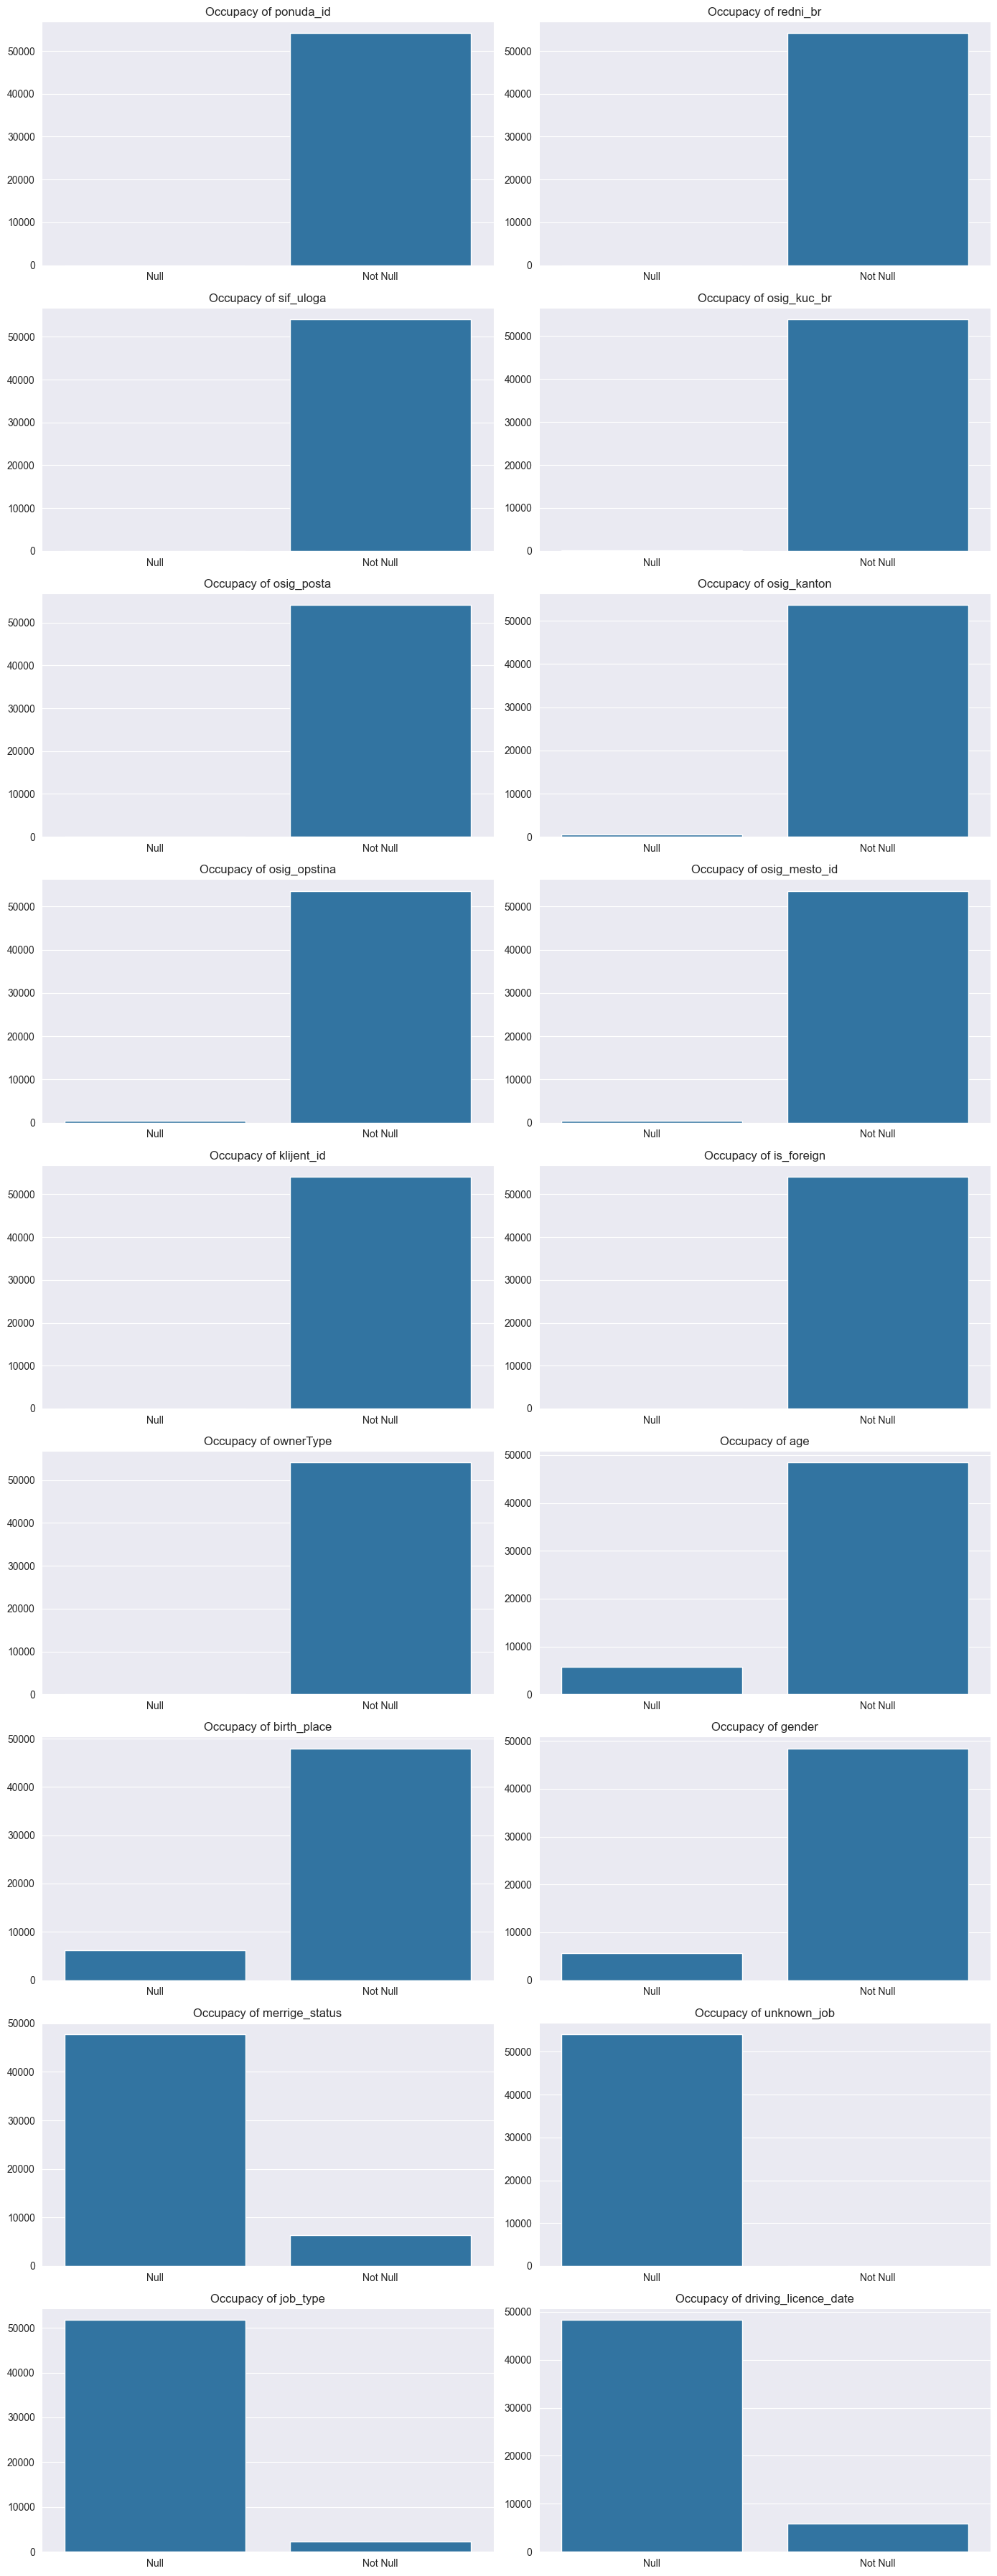

In [20]:
def show_cols_distribution(df):
    cols = df.columns
    n = len(cols)
    
    rows = math.ceil(n / 2)
    
    sns.set_style('darkgrid')
    plt.figure(figsize=(14, rows * 4))
    
    for i, col in enumerate(cols):
        plt.subplot(rows, 2, i + 1)
        
        null_count = df[col].isna().sum()
        not_null_count = df[col].notna().sum()
        
        sns.barplot(
            x=['Null', 'Not Null'],
            y=[null_count, not_null_count]
        )
        
        plt.title(f'Occupacy of {col}')
    
    plt.tight_layout()
    plt.show()

client_columns = cli_data.columns

show_cols_distribution(cli_data)

<b>Brišemo unknown_job i job_type jer je uglanom bez unosa</b>

In [21]:
cli_data = cli_data.drop(['unknown_job', 'job_type'], axis=1)

<h1 style="color:red;">Feature engineering (Kreiranje i obrada ulaznih varijabli)</h1>

<p>age_bucket predstavlja grupe korisnika po godinama</p>
<p>Uzimamo driving_licencedate godinu, i racunamo koliko dugo ima vozacku, korisnike koji nemaju unesen datum popunjavamo sa medijanom njihovih godina</p>
<p>Isto radim za merrige_status ako nije unesen status kreiramo ga uzimajuci prosjek za godine korisnika</p>

In [22]:
def feature_engineering(df):

    df = df.copy()
    
    # -------------------------
    # AGE BUCKET
    # -------------------------
    df['age_bucket'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 50, 65, 100],
        labels=[0, 1, 2, 3, 4]
    )

    # -------------------------
    # DRIVING EXPERIENCE
    # -------------------------
    df['driving_licence_date'] = pd.to_datetime(df['driving_licence_date'], errors='coerce')
    today_year = pd.Timestamp.today().year

    df['driving_experience'] = today_year - df['driving_licence_date'].dt.year

    # 🔥 KLJUČNO: prebaci u float (fix za tvoj error)
    df['driving_experience'] = df['driving_experience'].astype(float)

    # Fill NA po age_bucket medianu
    df['driving_experience'] = df['driving_experience'].fillna(
        df.groupby('age_bucket', observed=True)['driving_experience'].transform('median')
    )

    # Fallback global median
    df['driving_experience'] = df['driving_experience'].fillna(
        df['driving_experience'].median()
    )

    # -------------------------
    # MERRIGE STATUS
    # -------------------------
    # (pretpostavka: numerički encoding, npr 0/1)
    df['merrige_status'] = df['merrige_status'].astype(float)

    df['merrige_status'] = df['merrige_status'].fillna(
        df.groupby('age_bucket', observed=True)['merrige_status'].transform('median')
    )

    df['merrige_status'] = df['merrige_status'].fillna(
        df['merrige_status'].median()
    )

    # -------------------------
    # CLEANUP
    # -------------------------
    df = df.drop('driving_licence_date', axis=1)

    return df

In [23]:
cli_data = feature_engineering(cli_data)

<b>Prosto uzimamo klijente sa godinama koje djeluju nerealno za ugovaraca < 18 i > 90, i upisujem im prosjek za taj tip klijenata</b>

In [24]:
corrupted_data_ids = cli_data[(cli_data['age'] < 18) | (cli_data['age'] > 90)]['klijent_id'].values

print(len(corrupted_data_ids))
print(corrupted_data_ids)

266
<IntegerArray>
[  713,   777,  2269,  2321,  3181,  3451,  3594,  3595,  3631,  3643,
 ...
 54594, 54629, 54630, 54740, 54853, 55140, 55345, 55420, 55424, 55625]
Length: 266, dtype: Int32


In [25]:
cli_data.loc[cli_data['klijent_id'].isin(corrupted_data_ids), 'age'] = cli_data.groupby(['merrige_status', 'osig_opstina'])['age'].transform('median')

In [26]:
cli_data[cli_data['klijent_id'].isin(corrupted_data_ids)]

,ponuda_id,redni_br,sif_uloga,osig_kuc_br,osig_posta,osig_kanton,osig_opstina,osig_mesto_id,klijent_id,is_foreign,ownerType,age,birth_place,gender,merrige_status,age_bucket,driving_experience
7494,1293,1,12,1,71210.0,99.0,78.0,1208.0,713,0,1,52.0,11,1.0,1.0,NaN,11.0
32190,1411,2,20,30,88220.0,8.0,54.0,1515.0,777,0,1,30.0,15,1.0,1.0,0,2.0
38812,56447,2,20,59,89000.0,99.0,107.0,198.0,2269,0,1,53.0,15,1.0,1.0,0,2.0
38938,4399,1,9,44,71212.0,9.0,78.0,1200.0,2321,0,1,52.0,22,1.0,1.0,NaN,11.0
41677,6374,2,20,229,78000.0,99.0,2.0,4.0,3181,0,1,51.0,11,1.0,1.0,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112848,93822,1,11,BB,74268.0,4.0,90.0,1233.0,55140,0,1,35.0,19,0.0,1.0,0,2.0
113385,94485,1,11,17,78000.0,99.0,2.0,4.0,55345,0,1,51.0,10,0.0,1.0,0,2.0
113469,94644,1,11,0,78204.0,99.0,2.0,23.0,55420,0,1,51.0,10,1.0,1.0,0,2.0
113250,94650,1,11,0,78000.0,99.0,2.0,4.0,55424,0,1,51.0,10,1.0,1.0,0,2.0


<h1 style="color:red;">REASSEMBLE KLIJENATA</h1>
<p>Nakon sto sam za svakog klijenta izvukao sto je moguce vise podataka na kraju ih merge-am sa originalnim svim klijentima kako bih imao ponuda_id-ove koji mi govore na kojoj polisi su oni klijenti zapravo</p>
<p>Ostavljamo polise samo za klijente koji imaju polisa_id, odnosno ponuda je zapravo postala polisa.</p>
<p>Čistim duplikate ako postoje (Ne postoje)</p>
<p>Merge-am klijente sa polisama</p>

In [27]:
cli_data = cli_data.merge(np_cli_data[['klijent_id', 'ponuda_id', 'sif_uloga']], on = 'klijent_id', how = 'inner')
cli_data['ponuda_id'] = cli_data['ponuda_id_y']
cli_data = cli_data.drop(['ponuda_id_y', 'ponuda_id_x'], axis = 1)
cli_data['sif_uloga'] = cli_data['sif_uloga_y']
cli_data = cli_data.drop(['sif_uloga_y', 'sif_uloga_x'], axis = 1)

In [29]:
print_duplicates(cli_data, ['ponuda_id'])
print_duplicates(cli_data, ['ponuda_id', 'sif_uloga'])
print_duplicates(cli_data, ['ponuda_id', 'klijent_id', 'sif_uloga'])



############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 23781
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 23665
Ukupno redova koji pripadaju duplikat grupama: 47446
############ END ##############




############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id', 'sif_uloga']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 130
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 115
Ukupno redova koji pripadaju duplikat grupama: 245
############ END ##############




############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id', 'klijent_id', 'sif_uloga']
Broji koliko ukupno ima d

In [30]:
policy_data = policy_data[
    policy_data['polisa_id'].notna() & (policy_data['polisa_id'] != 0)
]

policy_data = policy_data.drop_duplicates(subset=['polisa_id'])
policy_data = policy_data.drop_duplicates(subset=['ponuda_id'])

policy_client_data = policy_data.merge(cli_data, on = 'ponuda_id', how = 'left')

In [31]:
print(policy_client_data.shape)
policy_client_data.head()

(99198, 106)


,ponuda_id,polisa_id,sif_vrsta,polisa_no,broker_id,sif_org_jed,zamena_polise_no,ind_zamena,sif_preuzmi,preuzmi_no,preuzmi_id,ugo_jmbg,ugo_svojina,ugo_naziv,ugo_naziv1,ugo_ulica,ugo_kuc_br,ugo_mesto,ugo_posta,ugo_kanton,ugo_opstina,ugo_mesto_id,ugo_telefon1,ugo_telefon2,ugo_mail,osig_jmbg,osig_svojina,osig_naziv,osig_naziv1,osig_ulica,osig_kuc_br_x,osig_mesto,osig_posta_x,osig_kanton_x,osig_opstina_x,osig_mesto_id_x,osig_telefon1,osig_telefon2,osig_mail,sif_trajanja,dat_od_ug,dat_do_ug,dat_od,dat_do,time_od,time_do,br_dana,mesto_izdavanja,dat_izdavanja,mjesto_izdavanja,napomena,napomena_auto,napomena1,p_oper,p_date,p_session_id,sif_nac_plac,br_rata,dat_prve_rate,sif_napomena,premija_ukupno,opis_osiguravac,ind_user_skadenca,ind_obracun,suma_osiguranja,polisa_tarifa,veza_polise_no,ind_lock_skadenca,miro_polisa_no,uw_indikator,ind_uw_kontrola,ugo_isprava,osig_isprava,sif_ikanton,sif_iopstina,ugo_del,king_id,sif_datum_dospeca,sif_bankovni_racun,ugo_br_pasosa,osig_br_pasosa,konacna_premija,ind_nepravilni_otp_plan,ind_dug,ind_steta,registarski_broj_polise,akcija_id,godina,days_old,years_old,redni_br,osig_kuc_br_y,osig_posta_y,osig_kanton_y,osig_opstina_y,osig_mesto_id_y,klijent_id,is_foreign,ownerType,age,birth_place,gender,merrige_status,age_bucket,driving_experience,sif_uloga
0,144,3505052,6,134070,79,71,128939.0,D,NaN,0.0,10,4401624960008,2.0,OKRUŽNO JAVNO TUŽILAŠTVO,NaN,VLADIKE PLATONA,BB,Banja Luka,78000.0,99.0,2.0,4.0,051327480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-29,2025-03-29,2024-03-29,2025-03-29,23:59,23:59,366.0,NaN,2024-03-07,NaN,NaN,NaN,NaN,119,2024-03-06,NaN,0.0,1.0,NaN,95.0,489.99,NaN,N,NaN,44500.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1001419.0,0.0,1.0,NaN,NaN,NaN,NaN,N,N,NaN,NaN,2024,811,2.220397,1.0,BB,78000.0,99.0,2.0,4.0,103,0.0,0.0,NaN,NaN,NaN,1.0,NaN,11.0,12.0
1,152,3505258,6,134274,45,577,0.0,N,NaN,0.0,10,2901948170005,1.0,ZORAN,REDŽIĆ,MICE TODOROVIĆ,2,Sarajevo Centar,71000.0,9.0,77.0,1600.0,000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-31,2025-03-31,2024-03-31,2025-03-31,00:59,00:59,366.0,NaN,2024-03-19,NaN,NaN,NaN,NaN,7139,2024-03-06,NaN,1.0,12.0,NaN,95.0,388.19,NaN,N,NaN,20698.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1004564.0,0.0,2.0,NaN,NaN,388.19,NaN,N,N,NaN,NaN,2024,799,2.187543,1.0,2,71000.0,9.0,77.0,1600.0,111,0.0,1.0,78.0,17,1.0,3.0,4,26.0,12.0
2,157,3505543,6,134559,196,187,0.0,N,NaN,0.0,10,4401489900008,2.0,TEHNOŠPED D.O.O.,NaN,DONJE VODIČEVO,BB,Novi Grad,79220.0,99.0,11.0,134.0,061000000,NaN,NaN,4.200899e+12,2.0,RAIFFEISEN LEASING d.o.o. Sarajevo,NaN,Zmaja od Bosne,bb,Sarajevo Centar,71000.0,9.0,77.0,1600.0,NaN,NaN,NaN,2.0,2024-04-05,2025-04-05,2024-04-05,2025-04-05,23:59,23:59,366.0,NaN,2024-04-05,NaN,NaN,NaN,NaN,8181,2024-03-06,NaN,1.0,1.0,NaN,95.0,1317.19,NaN,N,NaN,146981.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1008047.0,0.0,2.0,NaN,NaN,NaN,NaN,N,N,NaN,NaN,2024,782,2.140999,2.0,bb,71000.0,9.0,77.0,1600.0,33,0.0,0.0,NaN,NaN,NaN,1.0,NaN,11.0,20.0
3,157,3505543,6,134559,196,187,0.0,N,NaN,0.0,10,4401489900008,2.0,TEHNOŠPED D.O.O.,NaN,DONJE VODIČEVO,BB,Novi Grad,79220.0,99.0,11.0,134.0,061000000,NaN,NaN,4.200899e+12,2.0,RAIFFEISEN LEASING d.o.o. Sarajevo,NaN,Zmaja od Bosne,bb,Sarajevo Centar,71000.0,9.0,77.0,1600.0,NaN,NaN,NaN,2.0,2024-04-05,2025-04-05,2024-04-05,2025-04-05,23:59,23:59,366.0,NaN,2024-04-05,NaN,NaN,NaN,NaN,8181,2024-03-06,NaN,1.0,1.0,NaN,95.0,1317.19,NaN,N,NaN,146981.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1008047.0,0.0,2.0,NaN,NaN,NaN,NaN,N,N,NaN,NaN,2024,782,2.140999,1.0,BB,79220.0,99.0,11.0,134.0,114,0.0,0.0,NaN,NaN,NaN,1.0,NaN,11.0,11.0
4,158,3505053,6,134071,84,8,128777.0,D,NaN,0.0,10,2610989165038,1.0,MILICA,JOKIĆ,JOVANA DUČIĆA,44A,Banja Luka,78000.0,99.0,2.0,4.0,065972222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-15,2025-03-15,2024-03-15,2025-03-15,23:59,23:59,366.0,NaN,2024-03-07,NaN,NaN,NaN,NaN,8059,2024-03-07,NaN,0.0,1.0,NaN,95.0,258.50,NaN,N,NaN,24900.0,03

In [32]:
print((policy_client_data.groupby('klijent_id').size() > 1).sum())
print((policy_client_data.groupby('klijent_id').size() == 1).sum())

11059
39646


In [33]:
print_duplicates(policy_client_data, ['ponuda_id'])
print_duplicates(policy_client_data, ['ponuda_id', 'sif_uloga'])
print_duplicates(policy_client_data, ['ponuda_id', 'klijent_id', 'sif_uloga'])



############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 21613
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 21525
Ukupno redova koji pripadaju duplikat grupama: 43138
############ END ##############




############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id', 'sif_uloga']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 107
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 95
Ukupno redova koji pripadaju duplikat grupama: 202
############ END ##############




############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id', 'klijent_id', 'sif_uloga']
Broji koliko ukupno ima du

<h1 style="color:red;">Grafički prikaz distribucije polisa</h1>

<p>policy_clients je broj redova za svaki klijent_id, u sustini broji koliko svaki klijent ima polisa</p>
<p>Dijelim policy_counts na 2 niza sa klijentima koji imaju tacno jednu polisu i vise od jedne i od toga pravim DataFrame.</p>
<p>Definisem sirinu i boju za obje kolone.</p>
<p>Seaborn zapravo koristi Matplotlib u pozadini i vraća ti:
👉 jedan <b>AxesSubplot (ili jednostavno Axes)</b>

To je objekat koji predstavlja jedan graf (plot) — sve što vidiš na slici:

osa x i y
barovi
naslov
oznake

Možeš ga zamisliti kao “platno” na kojem crtaš.</p>
<p><b>patches</b> su svi nacrtani oblici (shapes) na tom grafu.

U slučaju barplota:
👉 svaki bar (stub) je jedan patch (tačnije Rectangle)</p>
<p>plot i subplots oba vracaju fig i svoju instancu axes. plot se koristi za crtanje jednog grafa a subplots vise njih</p>
<p>plt.tight_layout() Automatski podešava razmake (spacing) između elemenata na grafu da se ništa ne preklapa.</p>

In [34]:
def show_cli_policy_distribution(df):
    sns.set_style("darkgrid")

    policy_counts = df.groupby('klijent_id').size()
    
    data = {
        "Only 1 policy": (policy_counts == 1).sum(),
        "More than 1 policy": (policy_counts > 1).sum()
    }
    
    plot_df = (
        pd.DataFrame({
            "category": list(data.keys()),
            "value": list(data.values())
        })
    )
    
    plt.figure(figsize=(8, 6))
    
    colors = ["#4C78A8", "#F58518"]
    
    ax = sns.barplot(
        data=plot_df,
        x="category",
        y="value",
        hue="category",     # 🔥 fix za future warning
        palette=colors,
        legend=False
    )
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height()):,}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=11
        )
    
    plt.title("Distribution of Clients by Number of Policies", fontsize=14, weight='bold')
    plt.xlabel("")
    plt.ylabel("Number of Clients")
    
    plt.tight_layout()
    plt.show()

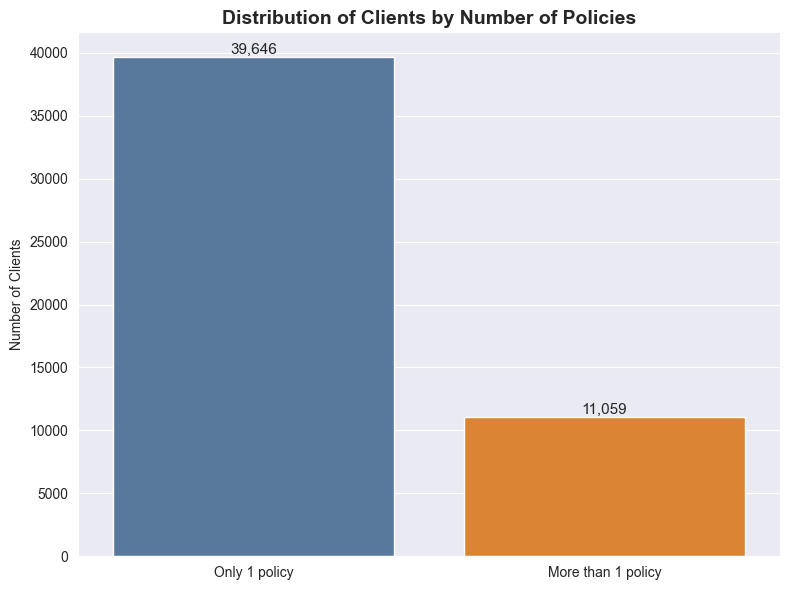

In [35]:
show_cli_policy_distribution(policy_client_data)

<h1 style="color:red;">Prosto izdvajam iskljuccivo klijente sa ulogom Ugovarac</h1>

In [36]:

cli_roles = cli_roles[cli_roles['opis'].str.contains('Ugovarač', na=False)]

In [38]:
policy_client_data = policy_client_data[policy_client_data['sif_uloga'].isin(cli_roles['sif_uloga'].values)]
print_duplicates(policy_client_data, ['ponuda_id'])



############ DUPLICATES CHECK ##############
############ EXPLOSION CHECK ##############
['ponuda_id']
Broji koliko ukupno ima duplikata znaci ako isti ponuda_id se popjavljuje 3 puta. To su vec 2 duplikata.... : 45
Broji koliko ima ponuda_idova sa duplikatima. Ako se isti ponuda_id pojavi 3 puta to je 1 red vec.... : 41
Ukupno redova koji pripadaju duplikat grupama: 86
############ END ##############




<h1 style="color: blue; font-weight: bold;">Brisanje duplikata</h1>

In [41]:
# policy_client_data.drop_duplicates('ponuda_id')

In [42]:
# maska za duplikate po ključu
mask = policy_client_data.duplicated(
    subset=['ponuda_id', 'klijent_id', 'sif_uloga'],
    keep=False
)

# svi redovi koji su duplikati
dupes = policy_client_data[mask]

print("Broj duplikat redova:", len(dupes))

Broj duplikat redova: 84


In [38]:
policy_client_data

,ponuda_id,polisa_id,sif_vrsta,polisa_no,broker_id,sif_org_jed,zamena_polise_no,ind_zamena,sif_preuzmi,preuzmi_no,preuzmi_id,ugo_jmbg,ugo_svojina,ugo_naziv,ugo_naziv1,ugo_ulica,ugo_kuc_br,ugo_mesto,ugo_posta,ugo_kanton,ugo_opstina,ugo_mesto_id,ugo_telefon1,ugo_telefon2,ugo_mail,osig_jmbg,osig_svojina,osig_naziv,osig_naziv1,osig_ulica,osig_kuc_br_x,osig_mesto,osig_posta_x,osig_kanton_x,osig_opstina_x,osig_mesto_id_x,osig_telefon1,osig_telefon2,osig_mail,sif_trajanja,dat_od_ug,dat_do_ug,dat_od,dat_do,time_od,time_do,br_dana,mesto_izdavanja,dat_izdavanja,mjesto_izdavanja,napomena,napomena_auto,napomena1,p_oper,p_date,p_session_id,sif_nac_plac,br_rata,dat_prve_rate,sif_napomena,premija_ukupno,opis_osiguravac,ind_user_skadenca,ind_obracun,suma_osiguranja,polisa_tarifa,veza_polise_no,ind_lock_skadenca,miro_polisa_no,uw_indikator,ind_uw_kontrola,ugo_isprava,osig_isprava,sif_ikanton,sif_iopstina,ugo_del,king_id,sif_datum_dospeca,sif_bankovni_racun,ugo_br_pasosa,osig_br_pasosa,konacna_premija,ind_nepravilni_otp_plan,ind_dug,ind_steta,registarski_broj_polise,akcija_id,godina,days_old,years_old,redni_br,osig_kuc_br_y,osig_posta_y,osig_kanton_y,osig_opstina_y,osig_mesto_id_y,klijent_id,is_foreign,ownerType,age,birth_place,gender,merrige_status,age_bucket,driving_experience,sif_uloga
0,144,3505052,6,134070,79,71,128939.0,D,NaN,0.0,10,4401624960008,2.0,OKRUŽNO JAVNO TUŽILAŠTVO,NaN,VLADIKE PLATONA,BB,Banja Luka,78000.0,99.0,2.0,4.0,051327480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-29,2025-03-29,2024-03-29,2025-03-29,23:59,23:59,366.0,NaN,2024-03-07,NaN,NaN,NaN,NaN,119,2024-03-06,NaN,0.0,1.0,NaN,95.0,489.99,NaN,N,NaN,44500.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1001419.0,0.0,1.0,NaN,NaN,NaN,NaN,N,N,NaN,NaN,2024,795,2.176591,1.0,BB,78000.0,99.0,2.0,4.0,103,0.0,0.0,NaN,NaN,NaN,1.0,NaN,11.0,12.0
1,152,3505258,6,134274,45,577,0.0,N,NaN,0.0,10,2901948170005,1.0,ZORAN,REDŽIĆ,MICE TODOROVIĆ,2,Sarajevo Centar,71000.0,9.0,77.0,1600.0,000000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-31,2025-03-31,2024-03-31,2025-03-31,00:59,00:59,366.0,NaN,2024-03-19,NaN,NaN,NaN,NaN,7139,2024-03-06,NaN,1.0,12.0,NaN,95.0,388.19,NaN,N,NaN,20698.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1004564.0,0.0,2.0,NaN,NaN,388.19,NaN,N,N,NaN,NaN,2024,783,2.143737,1.0,2,71000.0,9.0,77.0,1600.0,111,0.0,1.0,78.0,17,1.0,3.0,4,26.0,12.0
3,157,3505543,6,134559,196,187,0.0,N,NaN,0.0,10,4401489900008,2.0,TEHNOŠPED D.O.O.,NaN,DONJE VODIČEVO,BB,Novi Grad,79220.0,99.0,11.0,134.0,061000000,NaN,NaN,4.200899e+12,2.0,RAIFFEISEN LEASING d.o.o. Sarajevo,NaN,Zmaja od Bosne,bb,Sarajevo Centar,71000.0,9.0,77.0,1600.0,NaN,NaN,NaN,2.0,2024-04-05,2025-04-05,2024-04-05,2025-04-05,23:59,23:59,366.0,NaN,2024-04-05,NaN,NaN,NaN,NaN,8181,2024-03-06,NaN,1.0,1.0,NaN,95.0,1317.19,NaN,N,NaN,146981.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1008047.0,0.0,2.0,NaN,NaN,NaN,NaN,N,N,NaN,NaN,2024,766,2.097194,1.0,BB,79220.0,99.0,11.0,134.0,114,0.0,0.0,NaN,NaN,NaN,1.0,NaN,11.0,11.0
4,158,3505053,6,134071,84,8,128777.0,D,NaN,0.0,10,2610989165038,1.0,MILICA,JOKIĆ,JOVANA DUČIĆA,44A,Banja Luka,78000.0,99.0,2.0,4.0,065972222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-15,2025-03-15,2024-03-15,2025-03-15,23:59,23:59,366.0,NaN,2024-03-07,NaN,NaN,NaN,NaN,8059,2024-03-07,NaN,0.0,1.0,NaN,95.0,258.50,NaN,N,NaN,24900.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1001427.0,0.0,1.0,NaN,NaN,NaN,NaN,N,N,NaN,NaN,2024,795,2.176591,1.0,44A,78000.0,99.0,2.0,4.0,115,0.0,1.0,37.0,16,0.0,0.0,2,11.0,12.0
5,159,3505061,6,134078,70,532,128602.0,D,NaN,0.0,10,2212977181504,1.0,ELDIN,ŠABIĆ,PRVE SAMOSTALNE BRIGADE,11,ILIDŽA,71210.0,9.0,78.0,1208.0,061102662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2024-03-07,2025-03-07,2024-03-07,2025-03-07,23:59,23:59,366.0,NaN,2024-03-07,NaN,prijedlog prodaje,NaN,NaN,9055,2024-03-07,NaN,0.0,1.0,NaN,95.0,873.95,NaN,N,NaN,49700.0,03.01,NaN,N,NaN,N,N,NaN,NaN,NaN,NaN,NaN,1001697.0,0.0,2.0,NaN,

In [ ]:
show_cli_policy_distribution(policy_client_data)

In [ ]:
print(policy_client_data.columns.to_list())

In [ ]:
policy_client_data.head()

In [ ]:
len(policy_client_data[policy_client_data['polisa_id'] == 0])

<b>os.getpid() → vraća PID (process ID) trenutnog programa </b> <br>
<b>psutil.Process(...) → pravi objekat koji predstavlja taj proces</b><br>
<b>process = objekat preko kojeg možeš čitati:
    <ul>
        <li>memoriju</li>
        <li>CPU</li>
        <li>threadove</li>
        <li>itd.</li>
    </ul>
</b>
<b>psutil služi za pristup informacijama o sistemu i procesima iz Pythona. Jednostavno rečeno: 👉 omogućava ti da iz koda vidiš šta se dešava sa računarom i programima</b>

In [ ]:
process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / 1024 / 1024

<b>Oslobadjam memoriju rucnim garbage collectorom u pythonu gc ima smisla samo kada ostanu ne koristene reference</bc>

In [ ]:
before = get_ram_mb()

# policy_data = None
ins_cli_data = None
np_cli_data = None
cli_roles = None
cli_data = None

gc.collect()

after = get_ram_mb()

print(f"RAM prije: {before:.2f} MB")
print(f"RAM poslije: {after:.2f} MB")
print(f"Oslobođeno: {before - after:.2f} MB")

<b>Brisanje viska kolona</b>

In [ ]:
def clean_policy_client_data(df):

    df = df.copy()
    
    cols_to_delete = ['sif_preuzmi', 'preuzmi_no', 'preuzmi_id', 'ugo_jmbg', 'ugo_svojina', 'ugo_naziv', 'ugo_naziv1', 'ugo_ulica', 'ugo_kuc_br',
                      'ugo_mesto', 'ugo_posta', 'ugo_kanton', 'ugo_opstina', 'ugo_mesto_id', 'ugo_telefon1', 'ugo_telefon2', 'ugo_mail', 'osig_jmbg',
                      'osig_svojina', 'osig_naziv', 'osig_naziv1', 'osig_ulica', 'osig_kuc_br_x', 'osig_mesto', 'osig_posta_x', 'osig_kanton_x', 'osig_opstina_x',
                      'osig_mesto_id_x', 'osig_telefon1', 'osig_telefon2', 'osig_mail', 'mesto_izdavanja', 'miro_polisa_no', 'sif_ikanton', 'sif_iopstina', 'ugo_del', 'king_id',
                     'ugo_br_pasosa', 'osig_br_pasosa', 'registarski_broj_polise', 'akcija_id']

    df = df.drop(cols_to_delete, axis = 1)

    return df

In [ ]:
policy_client_data = clean_policy_client_data(policy_client_data)

<h1 style = "color: red;"> Jako vazno za iskoristiti </h1>
<ol>
    <b><li> zamenska polisa znaci da bi trebala biti polisa iz proslosti istog tipa ne mora biti iz ovog osiguranja</b></li>
    <b><li> sif_trajanja koliko traje, i po tom se obracunava...</li></b>
    <b><li> sif_nacin_placanja znaci da li je na rate, jednomjesecna, tromjesecna itd. povezano sa br rata</li></b>
    <b><li> sif_napomena od kada krece vazenje ugovora nema na svim samo na nekim.</li></b>
    <b><li> uw_indikator da li se nalazi na uw listi koa da mu je zabranjeno prodavati nalazi se na pepsi</li></b>
    <b><li> sif_datum_dospeca</li></b>
    <b><li> sif_bankovni racun na koji racun se placa fed ili RS</li></b>
    <b><li> ind_dug da li ima dug iz proslosti</li></b>
    <b><li> ind_steta da li ima stetu</li></b>
</ol>

<h1 style="color:red;">Markov model A implicira B (A → B) transition</h1>

<b style="color:black;">
Računamo vjerovatnoću prelaza između tipova polisa. 
Cilj je procijeniti kolika je vjerovatnoća da klijent uzme narednu polisu 
na osnovu trenutne (Markov pretpostavka).
</b>

---

## 🔹 Intuicija (šta model radi)

Za svakog klijenta posmatramo niz polisa kroz vrijeme:

A → B → C → B → D

Iz svih klijenata brojimo koliko puta se dešava prelaz:

- A → B  
- B → C  
- C → B  
- B → D  

Zatim računamo:

P(sljedeća polisa = B | trenutna = A)

---

## 🔹 Koraci u kodu

### 1. Inicijalizacija brojača
Koristimo Counter da brojimo prelaze između tipova polisa.

### 2. Grupisanje po klijentu
Podaci se grupišu po `klijent_id` jer se sekvence posmatraju unutar jednog klijenta.

### 3. Sortiranje po datumu
Polise se sortiraju po `dat_izdavanja` da bi se dobio pravilan redoslijed.

### 4. Ekstrakcija tipova polisa
Kolona `sif_vrsta` se pretvara u listu:
['A', 'B', 'C', 'B', 'D']

### 5. Formiranje prelaza
Iteriramo kroz uzastopne parove:
(A, B), (B, C), (C, B), (B, D)

### 6. Filtriranje istih uzastopnih vrijednosti
Preskaču se prelazi tipa A → A (opciono, zavisi od biznis logike)

### 7. Brojanje prelaza
Svaki prelaz (A, B) se broji u Counter strukturi.

### 8. Kreiranje DataFrame-a
Dobijamo tabelu:

| from_type | to_type | cnt |
|----------|--------|-----|
| A        | B      | 120 |
| B        | C      | 80  |

### 9. Računanje vjerovatnoća
Za svaki `from_type` normalizujemo:

P(B|A) = count(A → B) / suma svih prelaza iz A

---

## 🔹 Rezultat

Finalna tabela sadrži:

| from_type | to_type | cnt | prob |
|----------|--------|-----|------|
| A        | B      | 120 | 0.8  |
| A        | C      | 30  | 0.2  |


## 🔹 Moguća poboljšanja

- Uvesti vreminske težine (noviji podaci važniji)
- Koristiti top-N prelaza za preporuke

In [ ]:
from collections import Counter

def _build_markov_transition(df):
    trans = Counter()

    for _, g in df.groupby('klijent_id'):
        g = g.sort_values('dat_izdavanja')
        types = g['sif_vrsta'].tolist()

        for i in range(len(types) - 1):
            if types[i] != types[i+1]:
                trans[(types[i], types[i+1])] += 1

    out = pd.DataFrame(
        [(a, b, c) for (a, b), c in trans.items()],
        columns=['from_type', 'to_type', 'cnt']
    )

    out['prob'] = out.groupby('from_type')['cnt'].transform(lambda x: x / x.sum())

    return out

<h1 style="color:red;">Future pairs (Next-event learning)</h1>

<b style="color:black;">
Kreiramo dataset koji mapira svaku polisu na narednu polisu koju je klijent kupio.
Ovo se koristi za treniranje modela koji predviđa "šta je sljedeće".
</b>

---

## 🔹 Intuicija (šta model radi)

Za svakog klijenta posmatramo niz polisa:

A → B → C → B → D

Kreiramo parove:

- (A → B)
- (B → C)
- (C → B)
- (B → D)

Ali čuvamo samo:

👉 trenutnu polisu (anchor)  
👉 sljedeći tip polise (target)

---

## 🔹 Šta znači “future pairs”

Za svaku polisu pitamo:

👉 "Šta je klijent kupio nakon ove polise?"

Dobijamo dataset za supervised learning:

| ponuda_id | candidate_type | label |
|----------|---------------|------|
| 101      | B             | 1    |
| 102      | C             | 1    |

---

## 🔹 Koraci u kodu

### 1. Sortiranje podataka
Podaci se sortiraju po:
- `klijent_id`
- `dat_izdavanja`
- `ponuda_id`

Cilj: tačan vremenski redoslijed događaja.

---

### 2. Grupisanje po klijentu
Sekvence se posmatraju unutar jednog klijenta.

---

### 3. Ekstrakcija kolona
Kreiraju se liste:

- `ponuda_ids` → ID svake polise  
- `types` → tip polise (npr. A, B, C)

---

### 4. Iteracija kroz sekvencu
Prolazimo kroz sve uzastopne parove:

(A, B), (B, C), (C, B), (B, D)

---

### 5. Preskakanje istih tipova (opciono)
Ignorišu se prelazi tipa:

A → A

---

### 6. Kreiranje training parova

Za svaki validan prelaz dodajemo:

- `ponuda_id[i]` → trenutna polisa (anchor)
- `types[i+1]` → sljedeća polisa (target)

---

### 7. Kreiranje DataFrame-a

Dobijamo tabelu:

| ponuda_id | candidate_type |
|----------|---------------|
| 101      | B             |
| 102      | C             |

---

### 8. Uklanjanje duplikata
Ako se isti par pojavi više puta, zadržava se samo jedan.

---

### 9. Dodavanje label-a
Dodaje se kolona:

label = 1

👉 znači: ovo je stvarni (pozitivan) primjer

---

## 🔹 Finalni rezultat

Dataset spreman za ML model:

| ponuda_id | candidate_type | label |
|----------|---------------|------|
| 101      | B             | 1    |
| 102      | C             | 1    |

---

## 🔹 Kako se koristi dalje

Ovo su samo pozitivni primjeri.

Za treniranje modela potrebno je dodati:

❗ negativne primjere (label = 0)

npr:
- za istu polisu ponuditi tip koji NIJE kupljen

---

## 🔹 Razlika u odnosu na Markov model

| Markov model | Future pairs |
|-------------|------------|
| agregira prelaze | radi po pojedinačnom događaju |
| daje vjerovatnoće | daje training primjere |
| unsupervised | supervised learning |

---

## 🔹 Moguća poboljšanja

- dodati vremenske feature (razmak između polisa)
- uključiti self-transition (A → A)
- generisati negativne uzorke
- koristiti više koraka unaprijed (A → C, A → D)


In [ ]:
def _build_future_pairs(df):
    df = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()

    rows = []

    for _, g in df.groupby('klijent_id'):
        g = g.sort_values(['dat_izdavanja', 'ponuda_id'])

        ponuda_ids = g['ponuda_id'].tolist()
        types = g['sif_vrsta'].tolist()

        for i in range(len(types) - 1):

            if types[i] == types[i + 1]:
                continue

            rows.append((
                ponuda_ids[i],
                types[i + 1]
            ))

    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type'])
        .drop_duplicates()
        .assign(label=1)
    )

<h1 style="color:red;">Client History Matrix (kumulativna istorija polisa)</h1>

<p style="color:black;">
Ova funkcija za svaki događaj (polisu) pravi feature-e koji opisuju
<b>šta je klijent kupovao prije tog trenutka</b>.
</p>

<p style="color:black;">
Drugim riječima:
👉 za svaku polisu znaš koliko puta je klijent već imao svaku vrstu polise
</p>

---

<h2 style="color:red;">🔹 Intuicija (šta dobijamo)</h2>

<p style="color:black;">
Ako klijent ima sekvencu:
</p>

<pre>
A → B → A → C
</pre>

<p style="color:black;">
Dobijamo:
</p>

| event | trenutna | count_A | count_B | count_C |
|------|---------|--------|--------|--------|
| 1    | A       | 0      | 0      | 0      |
| 2    | B       | 1      | 0      | 0      |
| 3    | A       | 1      | 1      | 0      |
| 4    | C       | 2      | 1      | 0      |

<p style="color:black;">
👉 svaki red sadrži <b>istoriju prije tog eventa</b> (ne uključuje trenutni)
</p>

---

<h2 style="color:red;">🔹 Koraci u kodu</h2>

<ol>

<li>
<b>Sortiranje podataka</b>
<pre>
df.sort_values(['klijent_id', 'dat_izdavanja'])
</pre>
<small>
Osigurava tačan vremenski redoslijed po klijentu.
</small>
</li>

---

<li>
<b>One-hot encoding tipova polisa (U sustini anchor ce biti 1, a sve druge vrste 0 za svaki red to ce posle nivelisati shift(1))</b>
<pre>
pd.get_dummies(df['sif_vrsta'], prefix='type')
</pre>

<small>
Pretvara tipove u kolone:
</small>

<pre>
A → [1,0,0]
B → [0,1,0]
C → [0,0,1]
</pre>

</li>

---

<li>
<b>Formiranje baze</b>
<pre>
base = df[['klijent_id', 'dat_izdavanja', 'ponuda_id']]
</pre>

<small>
Zadržavamo osnovne identifikatore događaja.
</small>
</li>

---

<li>
<b>Spajanje (concat)</b>
<pre>
hist = pd.concat([base, dummies], axis=1)
</pre>

<small>
Svaki red sada ima:
</small>

<ul>
<li>klijent_id</li>
<li>datum</li>
<li>ponuda_id</li>
<li>one-hot tip polise</li>
</ul>

</li>

---

<li>
<b>Kumulativna suma po klijentu</b>
<pre>
groupby('klijent_id').cumsum()
</pre>

<small>
Računa koliko puta se svaka polisa pojavila do tog trenutka.
</small>

</li>

---

<li>
<b>Shift za 1 (ključni korak!)</b>
<pre>
.shift(1)
</pre>

<small>
Pomjera vrijednosti za jedan red unazad.
<br><br>
Time osiguravamo:
👉 trenutni event nije uključen u svoje feature-e
<br><br>

Bez shift:
<pre>
A → count_A = 1 ❌
</pre>

Sa shift:
<pre>
A → count_A = 0 ✅
</pre>

</small>
</li>

---

<li>
<b>Fill NaN sa 0</b>
<pre>
.fillna(0)
</pre>

<small>
Prvi događaj nema istoriju → postaje 0.
</small>
</li>

---

<li>
<b>Uklanjanje nepotrebnih kolona</b>
<pre>
drop(['klijent_id', 'dat_izdavanja'])
</pre>

<small>
Ostaje:
<ul>
<li>ponuda_id</li>
<li>feature-i (istorija)</li>
</ul>
</small>
</li>

</ol>

---

<h2 style="color:red;">🔹 Rezultat</h2>

<p style="color:black;">
DataFrame gdje svaki red predstavlja jedan događaj,
a kolone govore:
</p>

<ul>
<li>koliko puta je klijent imao svaku vrstu polise prije tog trenutka</li>
</ul>

---

<h2 style="color:red;">🔹 Zašto je ovo moćno</h2>

<ul>
<li>pretvara sekvencu u numeričke feature-e</li>
<li>pogodno za ML modele (XGBoost, LightGBM)</li>
<li>model dobija “kontekst” ponašanja klijenta</li>
</ul>

---

<h2 style="color:red;">🔹 Bitna napomena</h2>

<p style="color:black;">
<code>shift(1)</code> sprječava <b>data leakage</b>.
</p>

<p style="color:black;">
Bez toga bi model “vidio budućnost”.
</p>

---

<h2 style="color:red;">🔹 Moguća poboljšanja</h2>

<ul>
<li>normalizacija (npr. procenti umjesto count)</li>
<li>time-decay (novije polise važnije)</li>
<li>rolling window (npr. zadnjih 3 polise)</li>
</ul>

---

<h2 style="color:red;">🔹 Zaključak</h2>

<p style="color:black;">
Ova funkcija pravi “memory” klijenta —
model sada zna ne samo šta je klijent kupio,
nego i <b>koliko često i u kom kontekstu</b>.
</p>

In [ ]:
# def _build_client_history_matrix(df):
#     df = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()

#     dummies = pd.get_dummies(df['sif_vrsta'], prefix='type')

#     base = df[['klijent_id', 'dat_izdavanja', 'ponuda_id']].reset_index(drop=True)

#     hist = pd.concat([base, dummies.reset_index(drop=True)], axis=1)

#     hist[dummies.columns] = hist.groupby('klijent_id')[dummies.columns].cumsum()

#     hist[dummies.columns] = hist.groupby('klijent_id')[dummies.columns].shift(1).fillna(0)

#     hist = hist.drop(['klijent_id', 'dat_izdavanja'], axis = 1)


#     return hist

def _build_client_history_matrix(df):

    df = df.sort_values(['klijent_id', 'dat_izdavanja']).copy()

    dummies = pd.get_dummies(df['sif_vrsta'], prefix='type')

    hist = pd.concat(
        [df[['klijent_id', 'dat_izdavanja', 'ponuda_id']].reset_index(drop=True),
         dummies.reset_index(drop=True)],
        axis=1
    )

    feature_cols = dummies.columns

    # FIX: groupby uses SAME dataframe (no external alignment risk)
    hist[feature_cols] = (
        hist.groupby(hist['klijent_id'])[feature_cols]
        .cumsum()
        .groupby(hist['klijent_id'])
        .shift(1)
        .fillna(0)
    )

    # OPTIONAL SAFETY CHECK
    assert hist[['ponuda_id']].duplicated().sum() >= 0  # no explosion here

    return hist

<h1 style="color:red;">Definisanje ulaza i izlaza</h1>

In [ ]:
features = [
            'label', 'klijent_id', 'ponuda_id', 'sif_vrsta', 
            'n_policies_before', 'had_type_before', 'dat_izdavanja', 'days_since_last_policy',
            'candidate_type', 'cnt_type_before', 
            # Cooccurence fields
            'markov_prob', 
            'avg_premium_past', 'avg_insurance_sum_past', 'age', 'gender', 'ownerType', 'merrige_status', 'is_foreign',
            'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
            'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket'
        ]


training_features = [
            'n_policies_before', 'had_type_before', 'candidate_type', 'days_since_last_policy', 'cnt_type_before', 
            'markov_prob', 
            'avg_premium_past', 'avg_insurance_sum_past', 'age', 'gender', 'ownerType', 'merrige_status', 'is_foreign',
            'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
            'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket'
        ]

def _get_label(): return 'label'

def _get_categorical_training_features():
    return [
        'had_type_before', 'candidate_type', 'gender', 'ownerType', 'merrige_status', 'is_foreign', 'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
        'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket'
    ]

<h1 style="color:red;">Training Chunk Builder (dataset generation za ML)</h1>

<p style="color:black;">
Ova funkcija pravi <b>training dataset u chunk-ovima</b>
</p>

<p style="color:black;">
Ideja je:
👉 za svaki postojeći događaj (polisu) generišu se svi mogući budući kandidati polisa,
a zatim se dodaju feature-i:
</p>

<ul>
<li>Markov transition vjerovatnoće</li>
<li>istorija klijenta</li>
<li>label (da li se kandidat stvarno desio u budućnosti)</li>
</ul>

---

<h2 style="color:red;">🔹 Intuicija</h2>

<p style="color:black;">
Ako klijent trenutno ima:
</p>

<pre>
AUTO
</pre>

<p style="color:black;">
a kandidati su:
</p>

<pre>
AUTO
KASKO
IMOVINA
ZIVOT
</pre>

<p style="color:black;">
funkcija pravi:
</p>

| trenutna | kandidat | markov_prob | hist_auto | hist_kasko | label |
|---|---|---|---|---|---|
| AUTO | AUTO | 0.10 | 2 | 0 | 0 |
| AUTO | KASKO | 0.65 | 2 | 0 | 1 |
| AUTO | IMOVINA | 0.15 | 2 | 0 | 0 |
| AUTO | ZIVOT | 0.05 | 2 | 0 | 0 |

---

<h2 style="color:red;">🔹 Koraci u kodu</h2>

<ol>

<li>
<b>Kopiranje DataFrame-a</b>

<pre>
df = df.copy()
</pre>

<small>
Pravi sigurnu kopiju podataka da se original ne mijenja.
</small>

</li>

---

<li>

<b>Kreiranje foldera za chunk-ove</b>

<pre>
os.makedirs(chunks_dir, exist_ok=True)
</pre>

<small>
Pravi direktorij gdje će se spremati .pkl fajlovi.
</small>

</li>

---

<li>

<b>Podjela na chunk-ove</b>

<pre>
for i, start in enumerate(range(0, len(df), chunk_size)):
</pre>

<small>
Veliki dataset se dijeli na manje dijelove:
</small>

<pre>
0-5000
5000-10000
10000-15000
...
</pre>

<small>
👉 smanjuje RAM usage  
👉 omogućava trening na ogromnim datasetima
</small>

</li>

---

<li>

<b>Uzimanje jednog chunk-a</b>

<pre>
chunk = df.iloc[start:start + chunk_size].copy()
</pre>

<small>
Uzima se samo mali dio glavnog dataset-a.
</small>

</li>

---

<li>

<b>Uzimanje klijenata i datuma</b>

<pre>
chunk_klijenti = chunk['klijent_id'].unique()
chunk_datumi = chunk['dat_izdavanja'].unique()
</pre>

<small>
Dobijamo:
<ul>
<li>jedinstvene klijente</li>
<li>jedinstvene datume</li>
</ul>

iz trenutnog chunk-a.
</small>

</li>

---

<li>

<b>Cross Join (ključni dio)</b>

<pre>
chunk.assign(key=1).merge(
    candidates.assign(key=1),
    on='key'
)
</pre>

<small>
Pravi:
</small>

<pre>
SVAKI EVENT
×
SVAKI TIP POLISE
</pre>

<small>
Ako chunk ima:
</small>

<pre>
5000 događaja
</pre>

<small>
i postoji:
</small>

<pre>
20 tipova polisa
</pre>

<small>
dobijamo:
</small>

<pre>
100000 redova
</pre>

</li>

---

<li>

<b>Dodavanje Markov vjerovatnoće</b>

<pre>
chunk_dataset['markov_prob']
</pre>

<small>
Koristi:
</small>

<pre>
(sif_vrsta, candidate_type)
</pre>

<small>
kao ključ za lookup u:
</small>

<pre>
mt_dict
</pre>

<small>
Primjer:
</small>

<pre>
AUTO -> KASKO = 0.65
</pre>

<small>
👉 model dobija informaciju:
</small>

<pre>
"Koliko često klijenti poslije ove polise kupuju ovu drugu?"
</pre>

</li>

---

<li>

<b>Fill NaN sa 0</b>

<pre>
.fillna(0)
</pre>

<small>
Ako tranzicija ne postoji:
</small>

<pre>
probability = 0
</pre>

</li>

---

<li>

<b>Spajanje istorije klijenta</b>

<pre>
chunk_dataset.merge(
    client_history,
    on='ponuda_id',
    how='left'
)
</pre>

<small>
Dodaju se feature-i poput:
</small>

| hist_auto | hist_kasko | hist_zivot |
|---|---|---|
| 2 | 1 | 0 |

<small>
👉 model sada zna:
<ul>
<li>šta je klijent ranije kupovao</li>
<li>koliko puta</li>
</ul>
</small>

</li>

---

<li>

<b>Fill istorije sa 0</b>

<pre>
chunk_dataset[history_cols] = chunk_dataset[history_cols].fillna(0)
</pre>

<small>
Ako klijent nema istoriju:
</small>

<pre>
0
</pre>

</li>

---

<li>

<b>Uzimanje samo relevantnih future pair-ova</b>

<pre>
future_pairs.loc[
    future_pairs.index.isin(chunk['ponuda_id'])
]
</pre>

<small>
Ne uzima se cijeli future dataset,
nego samo dio vezan za trenutni chunk.

👉 ogromna optimizacija memorije.
</small>

</li>

---

<li>

<b>Merge label-a</b>

<pre>
merge(
    on=['ponuda_id', 'candidate_type']
)
</pre>

<small>
Dodaje se:
</small>

<pre>
label = 1
</pre>

<small>
ako se kandidat stvarno desio u budućnosti.
</small>

</li>

---

<li>

<b>Fill NaN label-a</b>

<pre>
.fillna(0).astype(int)
</pre>

<small>
Ako kandidat nije buduća polisa:
</small>

<pre>
label = 0
</pre>

</li>

---

<li>

<b>Spremanje chunk-a</b>

<pre>
to_pickle(...)
</pre>

<small>
Svaki chunk se sprema posebno:
</small>

<pre>
chunk_0.pkl
chunk_1.pkl
chunk_2.pkl
</pre>

<small>
👉 dataset ne mora stati u RAM.
</small>

</li>

---

<li>

<b>Garbage collection</b>

<pre>
del chunk
gc.collect()
</pre>

<small>
Ručno oslobađa memoriju nakon svakog chunk-a.

Vrlo bitno kod velikih dataset-a.
</small>

</li>

</ol>

---

<h2 style="color:red;">🔹 Finalni dataset</h2>

<p style="color:black;">
Na kraju svaki red izgleda ovako:
</p>

| ponuda_id | trenutna | kandidat | markov_prob | hist_* | label |
|---|---|---|---|---|---|
| 101 | AUTO | KASKO | 0.65 | ... | 1 |

---

<h2 style="color:red;">🔹 Zašto je ovo moćno</h2>

<ul>
<li>pretvara sekvencijalne podatke u supervised ML problem</li>
<li>kombinuje Markov modele i istoriju klijenta</li>
<li>omogućava treniranje XGBoost / LightGBM modela</li>
<li>pravi recommendation engine za polise</li>
</ul>

---

<h2 style="color:red;">🔹 Šta model zapravo uči</h2>

<p style="color:black;">
Model pokušava naučiti:
</p>

<pre>
"Za ovog klijenta i ovu trenutnu polisu,
kolika je vjerovatnoća da će sljedeće kupiti baš ovu kandidat polisu?"
</pre>

---

<h2 style="color:red;">🔹 Bitna optimizacija</h2>

<pre>
chunk_size=5000
</pre>

<p style="color:black;">
Chunk processing sprječava:
</p>

<ul>
<li>memory overflow</li>
<li>prevelike DataFrame-ove</li>
<li>sporo procesiranje</li>
</ul>

---

<h2 style="color:red;">🔹 Moguća poboljšanja</h2>

<ul>
<li>negative sampling</li>
<li>time-decay feature-i</li>
<li>frequency normalization</li>
<li>recency feature-i</li>
<li>ranking modeli</li>
</ul>

---

<h2 style="color:red;">🔹 Zaključak</h2>

<p style="color:black;">
Ova funkcija pravi kompletan ML training dataset
iz sekvencijalnih podataka o polisama.
</p>

<p style="color:black;">
Model sada ne vidi samo šta klijent trenutno ima,
nego i:
</p>

<ul>
<li>istoriju ponašanja</li>
<li>vjerovatne tranzicije</li>
<li>buduće ishode</li>
<li>kontekst kupovine</li>
</ul>

<p style="color:black;">
👉 praktično praviš recommendation engine za polise.
</p>

In [ ]:
def _build_training_chunks(df, future_pairs, mt_dict, chunk_size=5000, chunks_dir='chunks_temp'):
    
    df = df.copy()
    
    os.makedirs(chunks_dir, exist_ok=True)
    n_chunks = (len(df) // chunk_size) + 1
    saved_chunks = 0

    for i, start in enumerate(tqdm(range(0, len(df), chunk_size), total=n_chunks, desc="Chunks", colour="green")):

        # DEFINING MY DATAFRAME TO WORK ON - CHUNK
        chunk = df.iloc[start:start + chunk_size].copy()
        print("############################## SAMO CHUNK ORIGINALA #######################################")
        print_duplicates(chunk, ['ponuda_id'])

        # GETTING UNIQUE CLIENTS/DATES FROM CHUNK
        chunk_klijenti = chunk['klijent_id'].unique()
        chunk_datumi = chunk['dat_izdavanja'].unique()

        # --- CROSS JOIN chunk × candidates ---
        # EVERY CLIENT JOINING EVERY POLICY TYPE AS FUTURE LABEL
        chunk_dataset = chunk.assign(key=1).merge(
            candidates.assign(key=1), on='key'
        ).drop('key', axis=1)

        #EXPLOSION CHECK
        print("############################## NAKON CROSS JOIN SVAKE POLISE SA SVIM KANDIDATIMA #######################################")
        print_duplicates(chunk_dataset, ['ponuda_id', 'candidate_type'])
        

        # MARKOV'S TRANSITIONS
        chunk_dataset['markov_prob'] = chunk_dataset.set_index(
            ['sif_vrsta', 'candidate_type']
        ).index.map(mt_dict)
        chunk_dataset['markov_prob'] = chunk_dataset['markov_prob'].fillna(0)

        #EXPLOSION CHECK
        print("############################## NAKON MERGE-A SA MARKOVLJEVIM VJEROVATNOCAMA #######################################")
        print_duplicates(chunk_dataset, ['ponuda_id', 'candidate_type'])

        # CLIENT HISTORY
        chunk_dataset = chunk_dataset.merge(
            client_history,
            on=['klijent_id', 'dat_izdavanja'],
            how='left'
        )
        history_cols = [c for c in client_history.columns if c != 'ponuda_id']
        chunk_dataset[history_cols] = chunk_dataset[history_cols].fillna(0)

        #EXPLOSION CHECK
        print("############################## NAKON MERGE-A SA ISTORIJOM KUPOVINE #######################################")
        print_duplicates(chunk_dataset, ['ponuda_id', 'candidate_type'])

        # --- LABEL MERGE ---
        # JUST TAKING FUTURE PAIRS ONLY FOR CLIENTS FROM THIS CHUNK
        future_pairs_chunk = future_pairs[
            future_pairs['ponuda_id'].isin(chunk['ponuda_id'])
        ]
        
        chunk_dataset = chunk_dataset.merge(
            future_pairs_chunk,
            on=['ponuda_id', 'candidate_type'],
            how='left'
        )

        #EXPLOSION CHECK
        print("############################## NAKON POSTAVLJANJA LABELE #######################################")
        print_duplicates(chunk_dataset, ['ponuda_id', 'candidate_type'])

        # FILL LABELS WITH NAN VALUE WITH 0
        chunk_dataset['label'] = chunk_dataset['label'].fillna(0).astype(int)

        # Spremi na disk
        keep_cols = features
        chunk_dataset[keep_cols].to_pickle(f'{chunks_dir}/chunk_{i}.pkl')
        # chunk_dataset.to_pickle(f'{chunks_dir}/chunk_{i}.pkl')
        saved_chunks += 1

        del chunk, chunk_dataset, future_pairs_chunk
        gc.collect()

    return saved_chunks, chunks_dir

<h1 style="color:red;">Merge prethodnih chunkova</h1>

<p style="color:black;">
<b>Prosto citam sve chunkove iii stakujem ih po redovima. Nakon sto su svi ucitani brisem ih sa diska.</b>
</p>


In [ ]:
def merge_chunks(saved_chunks, chunks_dir):
    dataset = pd.concat([
        pd.read_pickle(f'{chunks_dir}/chunk_{i}.pkl')
        for i in range(saved_chunks)
    ], ignore_index=True)
    print(f"   Final dataset shape: {dataset.shape}")
    
    shutil.rmtree(chunks_dir)
    
    print("✅ Done!")
    return dataset, features

<h1 style="color:red;">ML Dataset Pipeline (priprema podataka za recommendation model)</h1>

<p style="color:black;">
Ovaj pipeline priprema kompletan dataset za trening recommendation / prediction modela.
</p>

<p style="color:black;">
Cilj je:
👉 iz istorije polisa naučiti šta će klijent vjerovatno kupiti sljedeće.
</p>

<p style="color:black;">
Pipeline:
</p>

<ul>
<li>čisti podatke</li>
<li>gradi istorijske feature-e</li>
<li>gradi Markov transition vjerovatnoće</li>
<li>gradi future labels</li>
<li>pravi candidate dataset</li>
<li>sprema chunk-ove za trening</li>
</ul>

---

<h2 style="color:red;">🔹 Intuicija</h2>

<p style="color:black;">
Ako klijent ima istoriju:
</p>

<pre>
AUTO → KASKO → IMOVINA
</pre>

<p style="color:black;">
model pokušava naučiti:
</p>

<pre>
"Šta će klijent vjerovatno kupiti nakon trenutne polise?"
</pre>

<p style="color:black;">
Na kraju dataset izgleda ovako:
</p>

| trenutna | kandidat | markov_prob | cnt_before | avg_premium | label |
|---|---|---|---|---|---|
| AUTO | KASKO | 0.65 | 2 | 150 | 1 |
| AUTO | ZIVOT | 0.05 | 2 | 150 | 0 |

---

<h2 style="color:red;">🔹 Koraci u pipeline-u</h2>

<ol>

<li>

<b>Filtriranje klijenata</b>

<pre>
df.groupby('klijent_id').filter(lambda x: len(x) > 1)
</pre>

<small>
Zadržavaju se samo klijenti koji imaju više od jedne polise.
</small>

<small>
👉 recommendation model nema smisla za klijente sa samo jednom polisom
jer nema sekvence ponašanja.
</small>

</li>

---

<li>

<b>Cleaning & sorting</b>

<pre>
df['dat_izdavanja'] = pd.to_datetime(df['dat_izdavanja'])

df.sort_values(['klijent_id', 'dat_izdavanja'])
</pre>

<small>
Osigurava:
</small>

<ul>
<li>ispravan datetime format</li>
<li>tačan vremenski redoslijed događaja</li>
</ul>

<small>
👉 veoma bitno za sequential learning
</small>

</li>

---

<li>

<b>Days since last policy</b>

<pre>
groupby('klijent_id')['dat_izdavanja'].diff().dt.days
</pre>

<small>
Računa koliko je dana prošlo od prethodne polise.
</small>

<p style="color:black;">
Primjer:
</p>

| polisa | days_since_last_policy |
|---|---|
| AUTO | NaN |
| KASKO | 30 |
| IMOVINA | 180 |

<small>
👉 model uči temporalni obrazac kupovine.
</small>

</li>

---

<li>

<b>Broj prethodnih polisa</b>

<pre>
cumcount()
</pre>

<small>
Računa koliko je klijent imao polisa prije trenutne.
</small>

| polisa | n_policies_before |
|---|---|
| AUTO | 0 |
| KASKO | 1 |
| IMOVINA | 2 |

<small>
👉 model vidi koliko je klijent "iskusan"
</small>

</li>

---

<li>

<b>Broj prethodnih polisa istog tipa</b>

<pre>
groupby(['klijent_id', 'sif_vrsta']).cumcount()
</pre>

<small>
Računa koliko puta je klijent već imao isti tip polise.
</small>

| polisa | cnt_type_before |
|---|---|
| AUTO | 0 |
| AUTO | 1 |
| AUTO | 2 |

<small>
👉 model vidi preference klijenta
</small>

</li>

---

<li>

<b>Da li je tip već postojao</b>

<pre>
(df['cnt_type_before'] > 0).astype(int)
</pre>

<small>
Pretvara count u binary feature:
</small>

| count | had_type_before |
|---|---|
| 0 | 0 |
| 1 | 1 |
| 5 | 1 |

<small>
👉 model vidi:
</small>

<pre>
"Da li je klijent ikad imao ovu vrstu?"
</pre>

</li>

---

<li>

<b>Rolling average premium</b>

<pre>
rolling(3).mean()
</pre>

<small>
Računa prosječnu premiju zadnje 3 polise.
</small>

| polisa | avg_premium_past |
|---|---|
| 1 | 100 |
| 2 | 125 |
| 3 | 150 |

<small>
👉 model vidi finansijski obrazac klijenta
</small>

</li>

---

<li>

<b>Rolling average insurance sum</b>

<pre>
rolling(3).mean()
</pre>

<small>
Računa prosječnu sumu osiguranja iz prethodnih polisa.
</small>

<small>
👉 model dobija informaciju o "veličini" klijenta
</small>

</li>

---

<li>

<b>Train / Validation split</b>

<pre>
train_df = df[df['dat_izdavanja'] < '2025-12-01']
val_df   = df[df['dat_izdavanja'] >= '2025-12-01']
</pre>

<small>
Dataset se dijeli vremenski.
</small>

<small>
👉 veoma bitno kod sekvencijalnih podataka
</small>

<small>
Model trenira na prošlosti,
a validira se na budućnosti.
</small>

</li>

---

<li>

<b>Markov transition matrix</b>

<pre>
_build_markov_transition(train_df)
</pre>

<small>
Računa vjerovatnoće prelaza između tipova polisa.
</small>

| from | to | probability |
|---|---|---|
| AUTO | KASKO | 0.65 |
| AUTO | ZIVOT | 0.05 |

<small>
👉 model vidi sekvencijalne obrasce ponašanja
</small>

</li>

---

<li>

<b>Future pairs (labels)</b>

<pre>
_build_future_pairs(...)
</pre>

<small>
Generiše:
</small>

<pre>
(anchor policy, next purchased type)
</pre>

<p style="color:black;">
Primjer:
</p>

| trenutna | sljedeća |
|---|---|
| AUTO | KASKO |

<small>
👉 ovo postaje supervised learning label
</small>

</li>

---

<li>

<b>Candidate generation</b>

<pre>
candidates = pd.DataFrame({'candidate_type': all_types})
</pre>

<small>
Pravi listu svih mogućih kandidata.
</small>

<p style="color:black;">
Primjer:
</p>

<pre>
AUTO
KASKO
IMOVINA
ZIVOT
</pre>

<small>
👉 svaki event se poredi sa svim kandidatima
</small>

</li>

---

<li>

<b>Client history matrix</b>

<pre>
_build_client_history_matrix(df)
</pre>

<small>
Pravi feature-e:
</small>

| type_AUTO | type_KASKO |
|---|---|
| 2 | 1 |

<small>
👉 model sada zna:
</small>

<ul>
<li>šta je klijent ranije kupovao</li>
<li>koliko puta</li>
</ul>

</li>

---

<li>

<b>Uklanjanje poslednje polise</b>

<pre>
cumcount(ascending=False) != 0
</pre>

<small>
Uklanja poslednji event svakog klijenta.
</small>

<small>
👉 poslednja polisa nema "future label"
</small>

</li>

---

<li>

<b>Garbage collection</b>

<pre>
gc.collect()
</pre>

<small>
Ručno oslobađa memoriju.
</small>

<small>
👉 veoma bitno kod velikih dataset-a
</small>

</li>

---

<li>

<b>Chunk processing</b>

<pre>
_build_training_chunks(...)
</pre>

<small>
Veliki dataset se obrađuje u manjim chunk-ovima.
</small>

<small>
👉 sprječava memory overflow
</small>

</li>

---

<li>

<b>Konkatenacija chunk-ova</b>

<pre>
merge_chunks(...)
</pre>

<small>
Spaja sve chunk-ove u finalni dataset.
</small>

</li>

---

<li>

<b>Categorical features</b>

<pre>
astype('category')
</pre>

<small>
Optimizuje memoriju i ubrzava tree-based modele.
</small>

<small>
👉 posebno korisno za LightGBM / CatBoost
</small>

</li>

</ol>

---

<h2 style="color:red;">🔹 Finalni dataset</h2>

<p style="color:black;">
Na kraju svaki red predstavlja:
</p>

<pre>
(trenutna polisa, kandidat)
</pre>

<p style="color:black;">
sa svim istorijskim feature-ima i label-om.
</p>

| trenutna | kandidat | hist_* | markov_prob | label |
|---|---|---|---|---|
| AUTO | KASKO | ... | 0.65 | 1 |

---

<h2 style="color:red;">🔹 Šta model zapravo uči</h2>

<p style="color:black;">
Model pokušava naučiti:
</p>

<pre>
"Za ovog klijenta i ovu trenutnu polisu,
koja je vjerovatnoća da će sljedeće kupiti baš ovu kandidat policu?"
</pre>

---

<h2 style="color:red;">🔹 Zašto je ovo moćno</h2>

<ul>
<li>pretvara sekvencijalne podatke u supervised ML problem</li>
<li>kombinuje istoriju i tranzicije</li>
<li>hvata temporalne obrasce ponašanja</li>
<li>radi kao recommendation engine</li>
<li>skalabilno za velike dataset-e</li>
</ul>

---

<h2 style="color:red;">🔹 Moguća poboljšanja</h2>

<ul>
<li>negative sampling</li>
<li>recency feature-i</li>
<li>time-decay weighting</li>
<li>ranking modeli</li>
<li>sequence embeddings</li>
<li>Transformer / RNN modeli</li>
</ul>

---

<h2 style="color:red;">🔹 Zaključak</h2>

<p style="color:black;">
Ovaj pipeline praktično pretvara istoriju polisa
u recommendation sistem.
</p>

<p style="color:black;">
Model sada ne vidi samo:
</p>

<pre>
šta klijent trenutno ima
</pre>

<p style="color:black;">
nego i:
</p>

<ul>
<li>kako se ponašao kroz vrijeme</li>
<li>šta često kupuje</li>
<li>šta kupuje nakon čega</li>
<li>koliko često kupuje</li>
<li>kolika mu je prosječna vrijednost polisa</li>
</ul>

<p style="color:black;">
👉 praktično gradiš insurance recommendation engine.
</p>

In [ ]:
df = policy_client_data.copy()

df = df.groupby(['klijent_id']).filter(lambda x: len(x) > 1)

print(f'Ukupni broj polisa sa klijentima koji imaju vise od jedne polise {len(df)}')
print(f"Broj jedinstvenih klijenata {df['klijent_id'].nunique()}")

# df = df.groupby(['klijent_id', 'ponuda_id']).filter(lambda x: len(x) > 1)

# ---------------------------
# 1. CLEANING & SORTING
# ---------------------------
print("✅ [1/7] Cleaning & sorting...")
df['dat_izdavanja'] = pd.to_datetime(df['dat_izdavanja'])
df = df.sort_values(['klijent_id', 'dat_izdavanja']).reset_index(drop=True)


# ---------------------------
# 2. HISTORY FEATURES
# ---------------------------
print("✅ [2/7] Building history features...")
df['days_since_last_policy'] = df.groupby('klijent_id')['dat_izdavanja'].diff().dt.days
df['n_policies_before'] = df.groupby('klijent_id').cumcount()
df['cnt_type_before'] = df.groupby(['klijent_id', 'sif_vrsta']).cumcount()
df['had_type_before'] = (df['cnt_type_before'] > 0).astype(int)

# df['avg_premium_past'] = (
#     df.groupby('klijent_id')['premija_ukupno']
#     .transform(lambda x: x.shift(1).expanding().mean())
# )
# df['avg_insurance_sum_past'] = (
#     df.groupby('klijent_id')['suma_osiguranja']
#     .transform(lambda x: x.shift(1).expanding().mean())
# )

# GROUP
g = df.groupby('klijent_id')

# FEATURES
df['avg_premium_past'] = (
    g['premija_ukupno']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df['avg_insurance_sum_past'] = (
    g['suma_osiguranja']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

train_df = df[df['dat_izdavanja'] < '2025-12-01']
val_df   = df[df['dat_izdavanja'] >= '2025-12-01']

# ---------------------------
# 3. CO-OCCURRENCE
# ---------------------------
print("✅ [3/7] Building co-occurrence matrix...")
# BUILDING MATRIX OF COUNT AND PROBABILITY FOR EVERY SIF_VRSTA TO HAD SAM SIF_VRSTA BEFORE
markov_transitions = _build_markov_transition(train_df)
mt_dict = markov_transitions.set_index(['from_type', 'to_type'])['prob'].to_dict()
    
print(f"   Co-occurrence shape: {markov_transitions.shape}")

# ---------------------------
# 4. FUTURE PAIRS (LABELS)
# ---------------------------
print("✅ [4/7] Building future pairs (labels)...")
future_pairs_train = _build_future_pairs(train_df)
future_pairs_val   = _build_future_pairs(val_df)

print(f"   Future pairs train shape: {future_pairs_train.shape}")
print(f"   Future pairs val shape: {future_pairs_val.shape}")





# ---------------------------
# 5. KANDIDATI
# ---------------------------
all_types = df['sif_vrsta'].unique()
candidates = pd.DataFrame({'candidate_type': all_types})
print(f"   Unique policy types (candidates): {len(all_types)}")

 # ---------------------------
# 6. CANDIDATE HISTORY LOOKUP (tačan, bez eksplozije)
# ---------------------------
print("✅ [5/7] Building candidate history lookup...")

client_history = _build_client_history_matrix(df)
features = features + [c for c in client_history.columns if c != 'ponuda_id']
print(f"   Anchor candidate history shape: {client_history.shape}")

# ---------------------------
# 7. REMOVING LAST POLICY
# ---------------------------

train_df = train_df.sort_values(['klijent_id', 'dat_izdavanja'])
val_df = val_df.sort_values(['klijent_id', 'dat_izdavanja'])


train_df = train_df[train_df.groupby('klijent_id').cumcount(ascending=False) != 0]
val_df   = val_df[val_df.groupby('klijent_id').cumcount(ascending=False) != 0]



print(f'Broj polisa nakon sto klijentima uklonim poslednju polisu koju su kupili {len(df)}')


gc.collect()

# ---------------------------
# 8. CHUNK PROCESSING
# ---------------------------
print("✅ [6/7] Processing chunks...")
# Gradi dataset zasebno
saved_chunks_train, train_dir = _build_training_chunks(train_df, future_pairs_train, mt_dict, chunk_size=5000, chunks_dir='chunks_temp_train')
saved_chunks_val, val_dir = _build_training_chunks(val_df,   future_pairs_val, mt_dict, chunk_size=5000, chunks_dir='chunks_temp_val')

# ---------------------------
# 9. KONKATENACIJA
# ---------------------------
print("✅ [7/7] Concatenating chunks...")

train_dataset, features_train = merge_chunks(saved_chunks_train, train_dir)
val_dataset, features_val = merge_chunks(saved_chunks_val, val_dir)


# DEFINING CATEGORY COLUMNS
cat_cols = _get_categorical_training_features()

for col in cat_cols:
    train_dataset[col] = train_dataset[col].astype('category')
    val_dataset[col] = val_dataset[col].astype('category')
    

In [ ]:
train_dataset['label'].value_counts(normalize=True)

In [ ]:
train_dataset[train_dataset['label'] == 1][['markov_prob']].describe()

<h1>Analiza <code>markov_prob</code> za pozitivnu klasu (<code>label == 1</code>)</h1>

<pre><code class="language-python">
train_dataset[train_dataset['label'] == 1][['markov_prob']].describe()
</code></pre>

<h2>Rezultati</h2>

<ul>
  <li>
    <strong>count = 7534</strong><br>
    → Imaš <strong>7534 pozitivna primjera</strong>.
  </li>

  <br>

  <li>
    <strong>mean = 0.304</strong><br>
    → Prosječna <code>markov_prob</code> vrijednost za pozitivne primjere je oko <strong>0.30</strong>.<br>
    👉 To znači da feature/model uglavnom ne daje veoma visoke vrijednosti za klasu <code>1</code>.
  </li>

  <br>

  <li>
    <strong>std = 0.224</strong><br>
    → Vrijednosti su dosta raspršene, odnosno postoji velika varijacija među primjerima.
  </li>
</ul>

<h2>Distribucija vrijednosti</h2>

<ul>
  <li>
    <strong>min = 0.0005</strong><br>
    → Najmanja vrijednost je skoro nula.
  </li>

  <br>

  <li>
    <strong>25% = 0.098</strong><br>
    → 25% pozitivnih primjera ima <code>markov_prob</code> manji od ~0.10.
  </li>

  <br>

  <li>
    <strong>50% (median) = 0.261</strong><br>
    → Polovina pozitivnih slučajeva ima vrijednost manju od ~0.26.
  </li>

  <br>

  <li>
    <strong>75% = 0.454</strong><br>
    → 75% slučajeva ima vrijednost manju od ~0.45.
  </li>

  <br>

  <li>
    <strong>max = 0.759</strong><br>
    → Maksimalna vrijednost nije ekstremno visoka.
  </li>
</ul>

<h2>Zaključak</h2>

<p>
  <code>markov_prob</code> za pozitivnu klasu (<code>label = 1</code>) uglavnom ima niske do srednje vrijednosti.
</p>

<p>To može značiti:</p>

<ul>
  <li>feature nema veoma jaku diskriminativnu moć samostalno</li>
  <li>postoji overlap između pozitivne i negativne klase</li>
  <li>model ili Markov procjena nisu dobro kalibrisani</li>
</ul>

In [ ]:
train_dataset[train_dataset['label'] == 0][['markov_prob']].describe()

In [ ]:
import matplotlib.pyplot as plt

# Pozitivna klasa
positive_probs = train_dataset[
    train_dataset['label'] == 1
]['markov_prob']

# Negativna klasa
negative_probs = train_dataset[
    train_dataset['label'] == 0
]['markov_prob']

# Plot
plt.figure(figsize=(12, 6))

plt.hist(
    negative_probs,
    bins=50,
    alpha=0.6,
    density=True,
    label='label = 0'
)

plt.hist(
    positive_probs,
    bins=50,
    alpha=0.6,
    density=True,
    label='label = 1'
)

plt.xlabel('markov_prob')
plt.ylabel('Density')
plt.title('Distribucija markov_prob po klasama')
plt.legend()

plt.show()

# Analiza distribucije `markov_prob` po klasama

## Klasa `label = 0`

Većina vrijednosti za negativnu klasu je:

- ekstremno blizu nule
- postoji ogroman spike oko `0.0`
- distribucija brzo opada nakon `0.05`

To znači da negativni primjeri uglavnom imaju veoma malu `markov_prob`.

---

# Klasa `label = 1`

Distribucija za pozitivnu klasu je:

- značajno pomjerena udesno
- ima mnogo više srednjih i visokih vrijednosti
- često se kreće u rasponu `0.1 - 0.6+`

To predstavlja veoma dobar signal.

---

# Najvažniji zaključak

Postoji vidljivo razdvajanje između klasa.

Vizuelno:

- plavi histogram (`label = 0`) dominira lijevo
- narandžasti histogram (`label = 1`) dominira desnije

To znači da `markov_prob` zaista nosi korisnu informaciju za predikciju.

---

# Overlap između klasa

I dalje postoji određeni overlap:

- dio pozitivnih primjera ima male vrijednosti
- dio negativnih primjera ima veće vrijednosti

Zbog toga feature nije savršen separator, ali je i dalje vjerovatno veoma koristan za model.

---

# Zanimljiva pojava

Kod pozitivne klase postoje izraženiji pikovi oko:

- `0.13`
- `0.39`
- `0.64`

To može značiti:

- Markov model proizvodi diskretne vjerovatnoće
- postoje specifični obrasci/stanja koji često vode do pozitivne klase

To može biti korisno za dalji feature engineering.

---

# Konačni zaključak

`markov_prob` djeluje kao kvalitetan feature jer:

✅ negativna klasa je koncentrisana blizu nule  
✅ pozitivna klasa je značajno pomjerena udesno  
✅ postoji realan prediktivni signal  

⚠️ Međutim, postoji overlap između klasa pa feature vjerovatno nije dovoljan samostalno.

Feature bi mogao biti veoma koristan u kombinaciji sa modelima kao što su:

- XGBoost
- LightGBM
- CatBoost
- Random Forest
- Logistic Regression

In [ ]:
train_dataset[train_dataset['ponuda_id'] == 119]

In [ ]:
client_history['ponuda_id'].duplicated().sum()

In [ ]:
future_pairs_train.groupby(['ponuda_id','candidate_type']).size().max()

In [ ]:
client_history.groupby('ponuda_id').size().sort_values(ascending=False).head(10)

In [ ]:
train_dataset.groupby('ponuda_id').size().head()

In [ ]:
type_cols = [
    c for c in train_dataset.columns
    if isinstance(c, str)
    and 'type' in c
    and pd.api.types.is_numeric_dtype(train_dataset[c])
]

train_dataset[type_cols].sum().head()

In [ ]:
train_dataset.sort_values(['klijent_id', 'dat_izdavanja']) \
       .groupby('klijent_id')['cnt_type_before'].head(10)

In [ ]:
train_dataset['cnt_type_before_log'] = np.log1p(train_dataset['cnt_type_before'])

In [ ]:
train_dataset[train_dataset['cnt_type_before'] < 0]

In [ ]:
train_dataset['markov_prob'].describe()

In [ ]:
# dataset['ponuda_id'].nunique()

In [ ]:
print(f'Original dataset length {len(policy_client_data)}')
print(f'Final dataset length {len(train_dataset)}')
print(f'Number of policy types {len(train_dataset) / len(policy_client_data)}')

In [ ]:
# Koliko labela imaš
print(f"Pozitivnih labela: {train_dataset['label'].sum()}")
print(f"Ukupno redova: {len(train_dataset)}")
print(f"Label rate: {train_dataset['label'].mean():.4f}")

In [ ]:
print(len(future_pairs_train))
print(len(policy_client_data))
print(len(train_dataset))

In [ ]:
print(train_dataset.columns)

In [ ]:
train_dataset.head()

In [ ]:
counts = policy_client_data.groupby('klijent_id').size()
max_id = counts.idxmax()
max_value = counts.max()
print(max_id)
print(max_value)

In [ ]:
counts = train_dataset.groupby('klijent_id').size()
max_id_2 = counts.idxmax()
max_value_2 = counts.max()
print(max_id_2)
print(max_value_2)

In [ ]:
print(max_value_2 / max_value)

In [ ]:
# -----------------------------
# 0. PRETPOSTAVKA
# -----------------------------
# dataset mora imati:
# klijent_id, sif_vrsta_anchor, candidate_type, label, dat_izdavanja + feature kolone

# -----------------------------
# 1. LIMITIRAJ KANDIDATE (BITNO!)
# -----------------------------
def cap_candidates(df, max_per_group=len(all_types) * 7):
    return (
        df
        .groupby(['klijent_id', 'dat_izdavanja'], group_keys=False)
        .head(max_per_group)
    )

train_dataset = cap_candidates(train_dataset)

# -----------------------------
# 2. SORT (OBAVEZNO ZA RANKING)
# -----------------------------
train_dataset = train_dataset.sort_values(
    ['klijent_id', 'dat_izdavanja']
).reset_index(drop=True)


X_train = train_dataset[training_features].copy()
for col in _get_categorical_training_features():
    X_train[col] = X_train[col].astype('category').cat.codes


y_train = train_dataset['label'].astype(int)

X_val = val_dataset[training_features].copy()
for col in _get_categorical_training_features():
    X_val[col] = X_val[col].astype('category').cat.codes


y_val = val_dataset['label'].astype(int)

# -----------------------------
# 4. GROUP (KLJUČNO!)
# -----------------------------
group = (
    train_dataset
    .groupby(['klijent_id', 'dat_izdavanja'])
    .size()
    .to_numpy()
)

# -----------------------------
# 5. SANITY CHECK (OBAVEZNO)
# -----------------------------
assert sum(group) == len(X_train), "❌ group i X nisu usklađeni!"

print("✅ Rows:", len(X_train))
print("✅ Groups:", len(group))
print("✅ Max group size:", group.max())

from lightgbm import log_evaluation


group_train = train_dataset.groupby(['klijent_id', 'dat_izdavanja']).size().to_numpy()
group_val = val_dataset.groupby(['klijent_id', 'dat_izdavanja']).size().to_numpy()

# -----------------------------
# 6. MODEL
# -----------------------------
model = LGBMRanker(
    objective='lambdarank',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31
)

# -----------------------------
# 7. FIT
# -----------------------------
model.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[1,3,5],
    callbacks=[log_evaluation(10)]
)

# Dodaj ovo nakon fit-anja modela:

# 1. Provjeri distribuciju skorova za tačne i netačne kandidate
scores_train = model.predict(X_train)
scores_val = model.predict(X_val)

print("=" * 50)
print("SCORE DISTRIBUCIJA")
print("=" * 50)

# Za training set
print("Training - Tačni kandidati (label=1):")
print(f"  Mean score: {scores_train[y_train==1].mean():.4f}")
print(f"  Std score: {scores_train[y_train==1].std():.4f}")
print(f"  Min score: {scores_train[y_train==1].min():.4f}")
print(f"  Max score: {scores_train[y_train==1].max():.4f}")

print("\nTraining - Netačni kandidati (label=0):")
print(f"  Mean score: {scores_train[y_train==0].mean():.4f}")
print(f"  Std score: {scores_train[y_train==0].std():.4f}")

# 2. Koliko tačnih kandidata je među top-3?
def relevant_in_top_k(model, X, y, group, k=3):
    start = 0
    relevant_in_top = 0
    total = 0
    
    for g in group:
        end = start + g
        preds = model.predict(X.iloc[start:end])
        labels = y.iloc[start:end].values
        
        # top_k_idx = np.argsort(preds)[-k:]
        top_k_idx = np.argsort(-preds)[:k]
        
        if np.any(labels[top_k_idx] == 1):
            relevant_in_top += 1
        total += 1
        start = end
    
    return relevant_in_top / total

print("\n" + "=" * 50)
print("RELEVANT IN TOP-K")
print("=" * 50)
for k in [1, 3, 5]:
    hr = relevant_in_top_k(model, X_val, y_val, group_val, k=k)
    print(f"HR@{k}: {hr:.4f}")

def ndcg_at_k(model, X, y, group, k=3):
    start = 0
    total_ndcg = 0
    n_groups = 0

    preds_all = model.predict(X)

    for g in group:
        end = start + g
        preds = preds_all[start:end]
        labels = y.iloc[start:end].values

        order = np.argsort(-preds)
        labels_sorted = labels[order][:k]

        dcg = np.sum(labels_sorted / np.log2(np.arange(2, k+2)))

        ideal = np.sort(labels)[::-1][:k]
        idcg = np.sum(ideal / np.log2(np.arange(2, k+2)))

        if idcg > 0:
            total_ndcg += dcg / idcg
            n_groups += 1

        start = end

    return total_ndcg / n_groups

In [ ]:
def hit_rate_at_k(model, X, y, group, k=1):
    """
    Hit Rate @k: Da li se relevantan item nalazi među top-k predikcija
    
    Args:
        model: trained model
        X: features DataFrame
        y: labels Series (1 for relevant, 0 for not)
        group: array of group sizes (each group = jedan query = jedan anchor)
        k: number of top predictions to consider
    """
    start = 0
    hits = 0
    total = 0
    
    for g in group:
        end = start + g
        
        # Predikcije za ovu grupu
        preds = model.predict(X.iloc[start:end])
        labels = y.iloc[start:end].values
        
        # Top-k indeksi
        top_k_idx = np.argsort(preds)[-k:]
        
        # Da li je neki od top-k relevantan?
        if np.any(labels[top_k_idx] == 1):
            hits += 1
        
        total += 1
        start = end
    
    return hits / total if total > 0 else 0.0

def mrr_at_k(model, X, y, group, k=5):
    """
    Mean Reciprocal Rank @k
    Reciprocal rank = 1 / position of first relevant item
    """
    start = 0
    reciprocal_ranks = []
    
    for g in group:
        end = start + g
        
        preds = model.predict(X.iloc[start:end])
        labels = y.iloc[start:end].values
        
        # Sortiraj po predikciji silazno
        sorted_idx = np.argsort(preds)[::-1]
        
        # Pronađi prvu relevantnu poziciju
        found = False
        for rank, idx in enumerate(sorted_idx[:k], 1):
            if labels[idx] == 1:
                reciprocal_ranks.append(1.0 / rank)
                found = True
                break
        
        if not found:
            reciprocal_ranks.append(0.0)
        
        start = end
    
    return np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0

# Test 1: Provjeri da li model može dobiti 1.0 na trening setu
train_preds = model.predict(X_train)
# Test 1: Training performance
train_hits = hit_rate_at_k(model, X_train, y_train, group_train, k=1)
print(f"Training HR@1: {train_hits:.4f}")

# Test 2: Validation performance  
val_hits = hit_rate_at_k(model, X_val, y_val, group_val, k=1)
print(f"Validation HR@1: {val_hits:.4f}")

# Test 3: Razlika između train i val
print(f"Overfitting gap: {train_hits - val_hits:.4f}")

# Test 4: MRR metrika
train_mrr = mrr_at_k(model, X_train, y_train, group_train, k=5)
val_mrr = mrr_at_k(model, X_val, y_val, group_val, k=5)
print(f"Training MRR@5: {train_mrr:.4f}")
print(f"Validation MRR@5: {val_mrr:.4f}")

# Test 5: Treniraj model BEZ vremenskih feature-a
X_no_time = X_train.drop(['cnt_type_before', 'n_policies_before', 'days_since_last_policy'], axis=1)
X_val_no_time = X_val.drop(['cnt_type_before', 'n_policies_before', 'days_since_last_policy'], axis=1)

model_no_time = LGBMRanker(
    objective='lambdarank',
    n_estimators=100,  # manje estimatora za brži test
    learning_rate=0.05,
    num_leaves=31,
    verbose=-1
)

model_no_time.fit(
    X_no_time, 
    y_train, 
    group=group_train,
    eval_set=[(X_val_no_time, y_val)],
    eval_group=[group_val],
    eval_at=[1,3,5],
    callbacks=[log_evaluation(20)]
)

# Test 6: Provjeri korelacije feature-a sa labelom
correlations = pd.DataFrame({
    'feature': X_train.columns,
    'correlation': [X_train[col].corr(y_train) for col in X_train.columns]
}).sort_values('correlation', ascending=False)
print("\nTop 10 feature correlations with label:")
print(correlations.head(10))

# Test 7: Provjeri markov_prob distribuciju po labeli
print("\nmarkov_prob statistics by label:")
print(train_dataset.groupby('label')['markov_prob'].describe())

# Test 8: Da li su ID-jevi u featurema?
id_cols = [c for c in X_train.columns if 'id' in c.lower() or 'klijent' in c.lower()]
print(f"\nPotencijalno problematicne kolone (ID-ovi): {id_cols}")

In [ ]:
# Dodaj ovo da provjeriš NDCG implementaciju
from sklearn.metrics import ndcg_score

def manual_ndcg_at_k(y_true, y_scores, k=1):
    """Ručna implementacija NDCG@k za jednu grupu"""
    # Sortiraj po score
    sorted_idx = np.argsort(y_scores)[::-1][:k]
    
    # DCG
    dcg = 0.0
    for i, idx in enumerate(sorted_idx):
        if y_true[idx] == 1:
            dcg += 1.0 / np.log2(i + 2)  # position i+1
    
    # IDCG (idealno - svi relevantni na prvim pozicijama)
    n_relevant = np.sum(y_true)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, n_relevant)))
    
    return dcg / idcg if idcg > 0 else 0.0

# Test na prvoj grupi
start = 0
first_group_size = group_val[0]
first_preds = model.predict(X_val.iloc[start:start+first_group_size])
first_labels = y_val.iloc[start:start+first_group_size].values

manual_ndcg = manual_ndcg_at_k(first_labels, first_preds, k=1)
print(f"Manual NDCG@1 for first group: {manual_ndcg:.4f}")
print(f"Expected (should match HR@1 concept): {1 if np.any(first_labels[np.argmax(first_preds)] == 1) else 0}")

In [ ]:
print("TRAIN:", model.evals_result_['training'])
print("VAL:", model.evals_result_['valid_0'])

In [ ]:
dataset.groupby(['klijent_id', 'dat_izdavanja']).size().describe()

In [ ]:
dataset.duplicated(subset=[
    'klijent_id',
    'dat_izdavanja',
    'candidate_type'
]).sum()

In [ ]:
print(dataset['dat_izdavanja'].min())
print(dataset['dat_izdavanja'].max())

In [ ]:
# random ranking baseline
y_random = np.random.rand(len(y_val))

# fake model score
print("BASELINE TEST")

In [ ]:
def hit_rate_at_k(model, X, y, group, k=1):
    start = 0
    hits = 0
    total = 0

    for g in group:
        end = start + g

        preds = model.predict(X.iloc[start:end])
        labels = y.iloc[start:end]

        top_k_idx = np.argsort(preds)[-k:]

        if labels.iloc[top_k_idx].sum() > 0:
            hits += 1

        total += 1
        start = end

    return hits / total

In [ ]:
import pandas as pd

fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(fi.head(10))

In [ ]:
y.mean()